# Nurse Scheduling under the Trustworthy-AI Lens

**Pietro Marco GALLO — Specialized Master in Trustworthy AI, CentraleSupélec — Université Paris-Saclay, 2026.**

Three approaches to the Nurse Scheduling Problem — exact MILP, simulated annealing, and an ML + MILP
hybrid — evaluated against four attributes of trustworthy AI: **critical-constraint satisfaction,
fairness, robustness, explainability**.

The full report is in the repository and is written in French; section, table and figure numbers below
refer to it.

| Section | Content | Output | First-run cost |
|---|---|---|---|
| §1 | Model: instance, MILP (cold/warm), ML features | — | s |
| §2 | 50 instances + MILP labels (180 s, 3 % gap) | dataset | ≈ 2 h |
| §3 | Simulated annealing | — | s |
| §4 | MILP vs SA @ 300 s, 10 test instances (SA: median over 10 seeds) | **Table 4** | ≈ 8 h |
| §5 | XGBoost + MLP training (seed 42) | models | ≈ 10 min |
| §6 | Hybrid JFI: 10 instances × 10 solver seeds × 2 models | **Table 5, warm column** | ≈ 17 h |
| §7 | Trajectories cold / warm-XGB / warm-MLP, 5→60 s budget | **Figure 1** | ≈ 35 min |
| §8 | SHAP analysis of the warm-start model (E3) | **Figure 3** | ≈ 5 min |
| §9 | Pareto fronts, weight calibration (E1) | **Figure 2** | ≈ 40 min |
| §10 | Robustness to disruptions P1–P3, MILP and SA | **Table 6** | ≈ 1.5 h |
| §11 | Stress test on N (D = 28 fixed), N = 24 → 17 | scaling figure | ≈ 40 min |
| §12 | 2×2 factorial design, post-submission | factorial table | ≈ 4.4 h |

Total for a cold start: **≈ 34 h**, dominated by §6 and §4. Every heavy step is cached, so a re-run
only recomputes what is missing; set `FORCE_RERUN = True` in the configuration cell to force
everything. §6 is resumable solve by solve.

**Prerequisite:** an active Gurobi licence able to handle ~2,900 binary variables (the size-limited
licence bundled with `pip install gurobipy` caps at 2,000 and is not sufficient).

In [1]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import torch
import torch.nn as nn
import shutil
import os

from dataclasses import dataclass, field
from typing import Optional
import random

In [2]:
FORCE_RERUN = False

In [ ]:
# ---------------------------------------------------------------------------
# Gurobi credentials are read from the environment - nothing is stored here.
# Set them before launching the notebook:
#
#   export GRB_WLSACCESSID="..."
#   export GRB_WLSSECRET="..."
#   export GRB_LICENSEID="..."
#
# On Colab, use the Secrets panel (key icon in the left sidebar) instead:
#   from google.colab import userdata
#   for k in ('GRB_WLSACCESSID', 'GRB_WLSSECRET', 'GRB_LICENSEID'):
#       os.environ[k] = userdata.get(k)
#
# A size-limited licence (bundled with `pip install gurobipy`) is NOT enough:
# the models here reach ~2,900 binary variables, above the 2,000 cap.
# ---------------------------------------------------------------------------
_missing = [k for k in ('GRB_WLSACCESSID', 'GRB_WLSSECRET', 'GRB_LICENSEID')
            if not os.environ.get(k)]
assert not _missing, f"Missing Gurobi credentials in the environment: {_missing}"

In [ ]:
# ====================================================================
# CELL 1 — Gurobi Setup
# ====================================================================
!pip install gurobipy --quiet

import gurobipy as gp
from gurobipy import GRB, quicksum

# Gurobi environment with academic license: use your own credentials here
GRB_ENV = gp.Env(params={
    "WLSAccessID": os.environ["GRB_WLSACCESSID"],
    "WLSSecret":   os.environ["GRB_WLSSECRET"],
    "LicenseID":   int(os.environ["GRB_LICENSEID"]),
})
GRB_ENV.start()

# Creation of the file to save results in Drive/local
try:
    from google.colab import drive
    drive.mount('/content/drive')
    RESULTS_DIR = '/content/drive/MyDrive/NSP_results'
except ImportError:
    RESULTS_DIR = os.environ.get('NSP_RESULTS', './NSP_results')
os.makedirs(RESULTS_DIR, exist_ok=True)

## §1 — Model: instance, MILP solver, features and warm-start pipeline
The basis model is the one from the report (§4): inter-shift rest of 8h via H3; `french_workcode=True` (control experiment §6.5) is optionally available to the solver to take into account the 11h law-enforced inter-shift rest.

In [6]:
# ====================================================================
# CELL 2 — NSPInstance class and reference instance
# ====================================================================

@dataclass
class NSPInstance:
    N: int
    D: int
    Req: dict
    pref: dict
    W_max: int = 5
    N_max: int = 4
    WE_min: int = 2
    weekend_days: set = field(default_factory=set)
    shifts: list = field(default_factory=lambda: ['M', 'A', 'N'])

    @property
    def shifts_all(self):
        return self.shifts + ['R']

    @property
    def weekend_pairs(self):
        return [(d, d+1) for d in range(self.D - 1)
                if d in self.weekend_days and (d+1) in self.weekend_days]


def create_reference_instance(seed: int = 42) -> NSPInstance:
    """Reference instance : N=25, D=28, 3 shifts + rest."""
    N, D = 25, 28
    weekend_days = {5, 6, 12, 13, 19, 20, 26, 27}  # Saturdays and Sundays if d=0=Monday

    req_semaine = {'M': 5, 'A': 4, 'N': 3}
    req_weekend = {'M': 4, 'A': 3, 'N': 3}
    Req = {
        (d, s): (req_weekend[s] if d in weekend_days else req_semaine[s])
        for d in range(D) for s in ['M', 'A', 'N']
    }

    rng = np.random.default_rng(seed=seed)
    pref = {
        (n, d, s): float(rng.beta(2, 2))
        for n in range(N) for d in range(D) for s in ['M', 'A', 'N']
    }

    return NSPInstance(
        N=N, D=D, Req=Req, pref=pref,
        W_max=5, N_max=4, WE_min=2,
        weekend_days=weekend_days,
    )


inst = create_reference_instance(seed=42)
print(f"Instance: N={inst.N}, D={inst.D}, all shifts={inst.shifts_all}")
print(f"Week total coverage: {sum(inst.Req[(0,s)] for s in inst.shifts)} people/day")
print(f"Weekend total coverage: {sum(inst.Req[(5,s)] for s in inst.shifts)} people/day")
print(f"# weekend pairs = {len(inst.weekend_pairs)}")

Instance: N=25, D=28, all shifts=['M', 'A', 'N', 'R']
Week total coverage: 12 people/day
Weekend total coverage: 10 people/day
# weekend pairs = 4


In [7]:
# ====================================================================
# CELLULE 3 — Fonction MILP + outils d'analyse
# ====================================================================

def extract_schedule(x, inst) -> pd.DataFrame:
    """Extract the schedule from the solved Gurobi variables."""
    schedule = []
    for n in range(inst.N):
        row = []
        for d in range(inst.D):
            assigned = None
            for s in inst.shifts_all:
                if x[n, d, s].X > 0.5:
                    assigned = s
                    break
            row.append(assigned)
        schedule.append(row)

    days = ['L', 'Ma', 'Me', 'J', 'V', 'S', 'D']
    columns = [f"{days[d % 7]}{d+1}" for d in range(inst.D)]
    return pd.DataFrame(schedule,
                        index=[f"Inf.{n}" for n in range(inst.N)],
                        columns=columns)


def style_schedule(df: pd.DataFrame):
    """Color the calendar by shift type."""
    color_map = {
        'M': 'background-color: #E8E8E8; color: #888',
        'A': 'background-color: #B4D8E7; color: black',
        'N': 'background-color: #4A5A7A; color: white',
        'R': 'background-color: #FFE5B4; color: black',
    }
    return df.style.map(lambda v: color_map.get(v, ''))


def schedule_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Statistics by nurse."""
    stats = pd.DataFrame(index=df.index)
    stats['Total'] = (df != 'R').sum(axis=1)
    stats['Matins'] = (df == 'M').sum(axis=1)
    stats['Après-midi'] = (df == 'A').sum(axis=1)
    stats['Nuits'] = (df == 'N').sum(axis=1)
    stats['Repos'] = (df == 'R').sum(axis=1)
    return stats


def verify_hard_constraints(df: pd.DataFrame, inst: NSPInstance) -> list:
    """Verifies a posteriori that H1-H6 are satisfied."""
    issues = []
    for d in range(inst.D):
        for s in inst.shifts:
            count = (df.iloc[:, d] == s).sum()
            if count < inst.Req[d, s]:
                issues.append(f"H2 violated: day {d}, shift {s}: {count} < {inst.Req[d,s]}")
    for n in range(inst.N):
        for d in range(inst.D - 1):
            if df.iloc[n, d] == 'N' and df.iloc[n, d+1] == 'M':
                issues.append(f"H3 violated: nurse {n}, days {d}->{d+1}")
        streak = 0
        for d in range(inst.D):
            if df.iloc[n, d] != 'R':
                streak += 1
                if streak > inst.W_max:
                    issues.append(f"H4 violated: nurse {n}, day {d} ({streak} consecutives)")
            else:
                streak = 0
        nights = (df.iloc[n, :] == 'N').sum()
        if nights > inst.N_max:
            issues.append(f"H5 violated: nurse {n} has {nights} > {inst.N_max} nights")
        free_we = sum(1 for (sat, sun) in inst.weekend_pairs
                      if df.iloc[n, sat] == 'R' and df.iloc[n, sun] == 'R')
        if free_we < inst.WE_min:
            issues.append(f"H6 violé: nurse {n} has {free_we} < {inst.WE_min} free WE")

    if not issues:
        print("✓ All hard constraints are satisfied.")
    else:
        print(f"✗ {len(issues)} violations:")
        for issue in issues[:10]:
            print(f"  - {issue}")
    return issues


def compute_trust_metrics(result: dict, inst: NSPInstance) -> dict:
    """Metrics of trustworthy AI."""
    df = result['schedule']
    W = (df != 'R').sum(axis=1).values.astype(float)
    nights = (df == 'N').sum(axis=1).values.astype(float)
    we_worked = np.array([
        sum(1 for d in inst.weekend_days if df.iloc[n, d] != 'R')
        for n in range(inst.N)
    ], dtype=float)

    def jain(v):
        s = (v ** 2).sum()
        return (v.sum() ** 2) / (len(v) * s) if s > 0 else 1.0

    total_work = int((df != 'R').sum().sum())
    pref_sum = sum(inst.pref[n, d, s]
                   for n in range(inst.N)
                   for d in range(inst.D)
                   for s in inst.shifts
                   if df.iloc[n, d] == s)

    return {
        'JFI_charges': jain(W),
        'JFI_nights': jain(nights),
        'JFI_weekends': jain(we_worked),
        'pref_mean': pref_sum / total_work if total_work > 0 else 0,
        **result['penalties'],
        'solve_time': result['solve_time'],
        'gap': result['gap'],
    }


def build_and_solve_milp(
    inst: NSPInstance,
    weights: Optional[dict] = None,
    time_limit: int = 300,
    mip_gap: float = 0.01,
    verbose: int = 1,
    french_workcode: bool = False
) -> dict:
    """Builds and resolves the MILP NSP."""
    if weights is None:
        weights = {'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5}

    m = gp.Model("NSP", env=GRB_ENV)
    m.Params.OutputFlag = verbose
    m.Params.TimeLimit = time_limit
    m.Params.MIPGap = mip_gap

    # === Variables ===
    x = m.addVars(
        [(n, d, s) for n in range(inst.N) for d in range(inst.D) for s in inst.shifts_all],
        vtype=GRB.BINARY, name="x"
    )

    # === Hard constraints ===
    m.addConstrs((quicksum(x[n, d, s] for s in inst.shifts_all) == 1
                  for n in range(inst.N) for d in range(inst.D)), name="H1")
    m.addConstrs((quicksum(x[n, d, s] for n in range(inst.N)) >= inst.Req[d, s]
                  for d in range(inst.D) for s in inst.shifts), name="H2")
    if french_workcode:
      m.addConstrs((x[n, d, 'N'] + x[n, d+1, 'A'] <= 1
                    for n in range(inst.N) for d in range(inst.D - 1)), name="H3")
      m.addConstrs((x[n, d, 'A'] + x[n, d+1, 'M'] <= 1
                    for n in range(inst.N) for d in range(inst.D - 1)), name="H3")
    m.addConstrs((x[n, d, 'N'] + x[n, d+1, 'M'] <= 1
                  for n in range(inst.N) for d in range(inst.D - 1)), name="H3")
    m.addConstrs((quicksum(x[n, d+k, s]
                           for k in range(inst.W_max + 1)
                           for s in inst.shifts) <= inst.W_max
                  for n in range(inst.N)
                  for d in range(inst.D - inst.W_max)), name="H4")
    m.addConstrs((quicksum(x[n, d, 'N'] for d in range(inst.D)) <= inst.N_max
                  for n in range(inst.N)), name="H5")

    weekend_pairs = inst.weekend_pairs
    f = m.addVars(
        [(n, w) for n in range(inst.N) for w in range(len(weekend_pairs))],
        vtype=GRB.BINARY, name="f"
    )
    for n in range(inst.N):
        for w, (sat, sun) in enumerate(weekend_pairs):
            m.addConstr(f[n, w] <= x[n, sat, 'R'])
            m.addConstr(f[n, w] <= x[n, sun, 'R'])
        m.addConstr(quicksum(f[n, w] for w in range(len(weekend_pairs))) >= inst.WE_min)

    # === Soft penalties ===
    P_pref = quicksum((1 - inst.pref[n, d, s]) * x[n, d, s]
                      for n in range(inst.N) for d in range(inst.D) for s in inst.shifts)

    c = m.addVars([(n, d) for n in range(inst.N) for d in range(inst.D - 1)],
                  vtype=GRB.BINARY, name="c")
    for n in range(inst.N):
        for d in range(inst.D - 1):
            for s in inst.shifts:
                m.addConstr(c[n, d] >= x[n, d, s] - x[n, d+1, s])
    P_cont = quicksum(c[n, d] for n in range(inst.N) for d in range(inst.D - 1))

    W = {n: quicksum(x[n, d, s] for d in range(inst.D) for s in inst.shifts)
         for n in range(inst.N)}
    W_bar = quicksum(W[n] for n in range(inst.N)) / inst.N
    delta_plus = m.addVars(range(inst.N), lb=0, name="dp")
    delta_minus = m.addVars(range(inst.N), lb=0, name="dm")
    for n in range(inst.N):
        m.addConstr(W[n] - W_bar == delta_plus[n] - delta_minus[n])
    P_eq = quicksum(delta_plus[n] + delta_minus[n] for n in range(inst.N))

    WE_work = {n: quicksum(x[n, d, s] for d in inst.weekend_days for s in inst.shifts)
               for n in range(inst.N)}
    total_we = sum(inst.Req[d, s] for d in inst.weekend_days for s in inst.shifts)
    WE_target = total_we / inst.N
    gamma_plus = m.addVars(range(inst.N), lb=0, name="gp")
    gamma_minus = m.addVars(range(inst.N), lb=0, name="gm")
    for n in range(inst.N):
        m.addConstr(WE_work[n] - WE_target == gamma_plus[n] - gamma_minus[n])
    P_we = quicksum(gamma_plus[n] + gamma_minus[n] for n in range(inst.N))

    # === Objective ===
    m.setObjective(
        weights['eq'] * P_eq + weights['we'] * P_we
        + weights['pref'] * P_pref + weights['cont'] * P_cont,
        GRB.MINIMIZE
    )

    m.optimize()

    result = {'status': m.Status, 'weights': weights, 'solve_time': m.Runtime}

    if m.SolCount > 0:
        p_eq = sum(delta_plus[n].X + delta_minus[n].X for n in range(inst.N))
        p_we = sum(gamma_plus[n].X + gamma_minus[n].X for n in range(inst.N))
        p_pref = sum((1 - inst.pref[n, d, s]) * x[n, d, s].X
                     for n in range(inst.N) for d in range(inst.D) for s in inst.shifts)
        p_cont = sum(c[n, d].X for n in range(inst.N) for d in range(inst.D - 1))

        result.update({
            'obj': m.ObjVal,
            'gap': m.MIPGap,
            'penalties': {'P_eq': p_eq, 'P_we': p_we, 'P_pref': p_pref, 'P_cont': p_cont},
            'schedule': extract_schedule(x, inst),
            'x_values': {k: v.X for k, v in x.items()},
        })
    else:
        result.update({'obj': None, 'gap': None})

    return result

In [8]:
# ====================================================================
# HYBRID — Cell 1 : Setup and instance generation functions
# ====================================================================

import itertools
from typing import List, Tuple

DATASET_DIR = f'{RESULTS_DIR}/hybrid_dataset'
os.makedirs(DATASET_DIR, exist_ok=True)


def create_instance_variant(
    N: int, D: int = 28, seed: int = 42,
    req_factor: float = 1.0,
) -> NSPInstance:
    """Generates a NSP instance with variable parameters"""
    weekend_days = {5, 6, 12, 13, 19, 20, 26, 27}

    req_semaine_base = {'M': 5, 'A': 4, 'N': 3}
    req_weekend_base = {'M': 4, 'A': 3, 'N': 3}

    # Demand variation (useful to diversify the dataset)
    req_semaine = {s: max(1, round(v * req_factor)) for s, v in req_semaine_base.items()}
    req_weekend = {s: max(1, round(v * req_factor)) for s, v in req_weekend_base.items()}

    Req = {
        (d, s): (req_weekend[s] if d in weekend_days else req_semaine[s])
        for d in range(D) for s in ['M', 'A', 'N']
    }

    rng = np.random.default_rng(seed=seed)
    pref = {
        (n, d, s): float(rng.beta(2, 2))
        for n in range(N) for d in range(D) for s in ['M', 'A', 'N']
    }

    return NSPInstance(
        N=N, D=D, Req=Req, pref=pref,
        W_max=5, N_max=4, WE_min=2,
        weekend_days=weekend_days,
    )


def generate_dataset_specs(n_instances: int = 50) -> List[dict]:
    """
    Définit les paramètres des 50 instances à générer.
    Varie N (taille du service) et seed (préférences).
    Évite N < 21 (infeasible) et N > 28 (trop facile).
    """
    N_values = [22, 23, 24, 25, 26, 27, 28]
    req_factors = [1.0]  # To simplify, we keep the demand fixed

    # Stratifies to have diversification
    specs = []
    seed = 0
    for N in N_values:
        n_per_N = n_instances // len(N_values) + (1 if N <= 25 else 0)
        for k in range(n_per_N):
            specs.append({
                'instance_id': len(specs),
                'N': N,
                'D': 28,
                'seed': seed,
                'req_factor': 1.0,
            })
            seed += 1
            if len(specs) >= n_instances:
                return specs[:n_instances]
    return specs[:n_instances]


# Preparation
specs = generate_dataset_specs(n_instances=50)
print(f"Dataset to generate : {len(specs)} instances")
print(f"Distribution N : {pd.Series([s['N'] for s in specs]).value_counts().sort_index().to_dict()}")

Dataset to generate : 50 instances
Distribution N : {22: 8, 23: 8, 24: 8, 25: 8, 26: 7, 27: 7, 28: 4}


In [9]:
def extract_features_from_instance(inst_params: dict) -> pd.DataFrame:
    """
    Extracts the features for EVERY triplet (n, d, s) of an instance.
    Returns a DataFrame with a line per triplet.
    """
    N = inst_params['N']
    D = inst_params['D']
    Req = inst_params['Req']
    pref = inst_params['pref']
    weekend_days_set = set(inst_params['weekend_days'])
    shifts_work = ['M', 'A', 'N']
    shifts_all = shifts_work + ['R']

    # === Precalculates at instance level ===
    pref_array = np.array([
        [[pref[(n, d, s)] for s in shifts_work] for d in range(D)]
        for n in range(N)
    ])  # shape (N, D, 3)

    pref_mean_n = pref_array.mean(axis=(1, 2))   # mean preference by nurse
    pref_std_n = pref_array.std(axis=(1, 2))
    pref_mean_d = pref_array.mean(axis=(0, 2))   # mean preference by day
    pref_mean_s = pref_array.mean(axis=(0, 1))   # mean preference by shift type

    # Global charge demanded by day
    daily_demand = np.array([
        sum(Req[(d, s)] for s in shifts_work) for d in range(D)
    ])  # shape (D,)

    # === Construction of the features triplet by triplet ===
    rows = []
    for n in range(N):
        for d in range(D):
            for s in shifts_all:
                is_weekend = d in weekend_days_set
                is_repos = (s == 'R')

                # Specific preference to the triplet (R = not applicable)
                pref_nds = pref[(n, d, s)] if s in shifts_work else 0.5

                # Relative preference: this shift with respect to the others for this nurse on this day
                if not is_repos:
                    prefs_day_n = np.array([pref[(n, d, s2)] for s2 in shifts_work])
                    pref_rank = (prefs_day_n < pref_nds).sum()  # 0, 1, ou 2
                    pref_relative = pref_nds - prefs_day_n.mean()
                else:
                    pref_rank = -1
                    pref_relative = 0.0

                # Demand / capacity ratio for this shift on this day
                if s in shifts_work:
                    req_ds = Req[(d, s)]
                    req_ratio = req_ds / N  # fraction of necessary nurses
                else:
                    req_ds = 0
                    req_ratio = 1 - daily_demand[d] / N  # expected rest ratio

                rows.append({
                    # === Identifiers ===
                    'n': n, 'd': d, 's': s,

                    # === Features at instance level ===
                    'inst_N': N,
                    'inst_D': D,
                    'inst_total_demand': daily_demand.sum(),
                    'inst_pref_mean': float(pref_array.mean()),

                    # === Features at nurse level ===
                    'n_pref_mean': pref_mean_n[n],
                    'n_pref_std': pref_std_n[n],
                    'n_pref_M_mean': pref_array[n, :, 0].mean(),
                    'n_pref_A_mean': pref_array[n, :, 1].mean(),
                    'n_pref_N_mean': pref_array[n, :, 2].mean(),

                    # === Features at day level ===
                    'd_pref_mean': pref_mean_d[d],
                    'd_daily_demand': daily_demand[d],
                    'd_is_weekend': int(is_weekend),
                    'd_day_of_week': d % 7,
                    'd_index_normalized': d / D,

                    # === Features at shift level ===
                    's_is_M': int(s == 'M'),
                    's_is_A': int(s == 'A'),
                    's_is_N': int(s == 'N'),
                    's_is_R': int(is_repos),
                    's_pref_mean_overall': pref_mean_s[shifts_work.index(s)] if s in shifts_work else 0.5,

                    # === Features triplet (n, d, s) ===
                    'nds_pref': pref_nds,
                    'nds_pref_rank': pref_rank,
                    'nds_pref_relative': pref_relative,
                    'nds_req': req_ds,
                    'nds_req_ratio': req_ratio,
                    'nds_n_pref_minus_avg': pref_nds - pref_mean_n[n] if not is_repos else 0.0,
                })

    return pd.DataFrame(rows)


def build_full_dataset(dataset_raw: list) -> pd.DataFrame:
    """
    Construit le DataFrame complet (features + target) à partir du dataset brut.
    Une ligne par triplet (n, d, s), avec colonne 'y' = 1 si x[n,d,s] = 1.
    """
    all_rows = []

    for record in dataset_raw:
        if not record.get('feasible', False):
            continue

        iid = record['instance_id']
        inst_params = record['inst_params']
        x_values = record['x_values']

        # Features for this instance
        df_features = extract_features_from_instance(inst_params)
        df_features['instance_id'] = iid
        df_features['N'] = record['N']
        df_features['seed'] = record['seed']

        # Binary target : y = x[n,d,s]
        df_features['y'] = df_features.apply(
            lambda row: int(x_values[(row['n'], row['d'], row['s'])] > 0.5),
            axis=1
        )

        all_rows.append(df_features)

    df = pd.concat(all_rows, ignore_index=True)
    print(f"Dataset complet : {len(df)} triplets ({df['instance_id'].nunique()} instances)")
    print(f"Distribution y : {df['y'].value_counts().to_dict()}")
    print(f"Class balance  : {df['y'].mean()*100:.1f}% positifs")

    return df

In [10]:
# ====================================================================
# HYBRID — Phase 4 : Complete pipeline and comparison cold vs warm
# ====================================================================

import torch

def predict_warm_start(inst: NSPInstance, ml_model, scaler=None,
                       model_type: str = 'xgb') -> dict:
    """
    Prédit une affectation warm-start à partir des features de l'instance.
    Retourne {(n, d, s): probabilité} et {(n, d, s): valeur binaire}.
    """
    inst_params = {
        'N': inst.N, 'D': inst.D, 'Req': dict(inst.Req),
        'pref': dict(inst.pref), 'weekend_days': list(inst.weekend_days),
    }
    df_inst = extract_features_from_instance(inst_params)
    X = df_inst[feature_cols].values

    if model_type == 'xgb':
        probs = ml_model.predict_proba(X)[:, 1]
    else:  # nn
        X_s = scaler.transform(X)
        ml_model.eval()
        with torch.no_grad():
            logits = ml_model(torch.FloatTensor(X_s).to(device))
            probs = torch.sigmoid(logits).cpu().numpy()

    # Reconstructs dict (n, d, s) -> probability
    pred_proba = {(r['n'], r['d'], r['s']): probs[i]
                  for i, (_, r) in enumerate(df_inst.iterrows())}

    # Projection towards a binary solution that satisfies H1 (unicity by cell)
    pred_binary = project_to_feasible_unique(pred_proba, inst)

    return {'probs': pred_proba, 'binary': pred_binary}


def project_to_feasible_unique(pred_proba: dict, inst: NSPInstance) -> dict:
    """
    For every (n, d), chooses the shift with the highest predicted probability.
    Guarantees H1 (one shift per cell).
    """
    binary = {}
    for n in range(inst.N):
        for d in range(inst.D):
            probs_nds = {s: pred_proba[(n, d, s)] for s in inst.shifts_all}
            chosen = max(probs_nds, key=probs_nds.get)
            for s in inst.shifts_all:
                binary[(n, d, s)] = 1 if s == chosen else 0
    return binary


def build_and_solve_milp_warmstart(
    inst: NSPInstance,
    warm_start_values: dict,
    weights: dict = None,
    time_limit: int = 300,
    mip_gap: float = 0.01,
    verbose: int = 1,
    french_workcode: bool = False
) -> dict:
    """
    Variant of build_and_solve_milp that passes a warm-start to Gurobi
    via x.Start. Everything else is identical to the cold version.
    """
    if weights is None:
        weights = {'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5}

    m = gp.Model("NSP_warm", env=GRB_ENV)
    m.Params.OutputFlag = verbose
    m.Params.TimeLimit = time_limit
    m.Params.MIPGap = mip_gap

    # === Variables (with warm-start) ===
    x = m.addVars(
        [(n, d, s) for n in range(inst.N) for d in range(inst.D) for s in inst.shifts_all],
        vtype=GRB.BINARY, name="x"
    )
    # WARM START: provides the initial value to Gurobi
    for (n, d, s), val in warm_start_values.items():
        x[n, d, s].Start = val

    # === Constraints and penalties: identic to build_and_solve_milp() ===

    # H1
    m.addConstrs((quicksum(x[n, d, s] for s in inst.shifts_all) == 1
                  for n in range(inst.N) for d in range(inst.D)), name="H1")
    # H2
    m.addConstrs((quicksum(x[n, d, s] for n in range(inst.N)) >= inst.Req[d, s]
                  for d in range(inst.D) for s in inst.shifts), name="H2")
    # H3
    m.addConstrs((x[n, d, 'N'] + x[n, d+1, 'M'] <= 1
                  for n in range(inst.N) for d in range(inst.D - 1)), name="H3")
    if french_workcode:
      m.addConstrs((x[n, d, 'N'] + x[n, d+1, 'A'] <= 1
                    for n in range(inst.N) for d in range(inst.D - 1)), name="H3")
      m.addConstrs((x[n, d, 'A'] + x[n, d+1, 'M'] <= 1
                    for n in range(inst.N) for d in range(inst.D - 1)), name="H3")
    # H4
    m.addConstrs((quicksum(x[n, d+k, s]
                           for k in range(inst.W_max + 1) for s in inst.shifts) <= inst.W_max
                  for n in range(inst.N)
                  for d in range(inst.D - inst.W_max)), name="H4")
    # H5
    m.addConstrs((quicksum(x[n, d, 'N'] for d in range(inst.D)) <= inst.N_max
                  for n in range(inst.N)), name="H5")
    # H6
    weekend_pairs = inst.weekend_pairs
    f = m.addVars([(n, w) for n in range(inst.N) for w in range(len(weekend_pairs))],
                  vtype=GRB.BINARY, name="f")
    for n in range(inst.N):
        for w, (sat, sun) in enumerate(weekend_pairs):
            m.addConstr(f[n, w] <= x[n, sat, 'R'])
            m.addConstr(f[n, w] <= x[n, sun, 'R'])
        m.addConstr(quicksum(f[n, w] for w in range(len(weekend_pairs))) >= inst.WE_min)

    # Soft penalties
    P_pref = quicksum((1 - inst.pref[n, d, s]) * x[n, d, s]
                      for n in range(inst.N) for d in range(inst.D) for s in inst.shifts)
    c = m.addVars([(n, d) for n in range(inst.N) for d in range(inst.D - 1)],
                  vtype=GRB.BINARY, name="c")
    for n in range(inst.N):
        for d in range(inst.D - 1):
            for s in inst.shifts:
                m.addConstr(c[n, d] >= x[n, d, s] - x[n, d+1, s])
    P_cont = quicksum(c[n, d] for n in range(inst.N) for d in range(inst.D - 1))

    W = {n: quicksum(x[n, d, s] for d in range(inst.D) for s in inst.shifts)
         for n in range(inst.N)}
    W_bar = quicksum(W[n] for n in range(inst.N)) / inst.N
    dp = m.addVars(range(inst.N), lb=0, name="dp")
    dm = m.addVars(range(inst.N), lb=0, name="dm")
    for n in range(inst.N):
        m.addConstr(W[n] - W_bar == dp[n] - dm[n])
    P_eq = quicksum(dp[n] + dm[n] for n in range(inst.N))

    WE_work = {n: quicksum(x[n, d, s] for d in inst.weekend_days for s in inst.shifts)
               for n in range(inst.N)}
    total_we = sum(inst.Req[d, s] for d in inst.weekend_days for s in inst.shifts)
    WE_target = total_we / inst.N
    gp_var = m.addVars(range(inst.N), lb=0, name="gp")
    gm_var = m.addVars(range(inst.N), lb=0, name="gm")
    for n in range(inst.N):
        m.addConstr(WE_work[n] - WE_target == gp_var[n] - gm_var[n])
    P_we = quicksum(gp_var[n] + gm_var[n] for n in range(inst.N))

    m.setObjective(
        weights['eq'] * P_eq + weights['we'] * P_we
        + weights['pref'] * P_pref + weights['cont'] * P_cont,
        GRB.MINIMIZE
    )

    # === Capture of the time-to-first-feasible ===
    # It registers when the first admissible solution appears
    feasibility_log = []
    def callback(model, where):
        if where == GRB.Callback.MIPSOL:
            t = model.cbGet(GRB.Callback.RUNTIME)
            obj = model.cbGet(GRB.Callback.MIPSOL_OBJ)
            feasibility_log.append({'time': t, 'obj': obj})

    m.optimize(callback)

    result = {
        'status': m.Status,
        'solve_time': m.Runtime,
        'feasibility_log': feasibility_log,
        'time_to_first_feasible': feasibility_log[0]['time'] if feasibility_log else None,
    }

    if m.SolCount > 0:
        p_eq = sum(dp[n].X + dm[n].X for n in range(inst.N))
        p_we = sum(gp_var[n].X + gm_var[n].X for n in range(inst.N))
        p_pref = sum((1 - inst.pref[n, d, s]) * x[n, d, s].X
                     for n in range(inst.N) for d in range(inst.D) for s in inst.shifts)
        p_cont = sum(c[n, d].X for n in range(inst.N) for d in range(inst.D - 1))
        result.update({
            'obj': m.ObjVal, 'gap': m.MIPGap,
            'penalties': {'P_eq': p_eq, 'P_we': p_we, 'P_pref': p_pref, 'P_cont': p_cont},
            'schedule': extract_schedule(x, inst),
        })

    return result

In [11]:
# Reference instance (N = 25, seed 42) - used by the stress test (§7)
inst = create_reference_instance(seed=42)
print(f"Reference instance : N={inst.N}, D={inst.D}, "
      f"Wmax={inst.W_max}, Nmax={inst.N_max}, WEmin={inst.WE_min}")


Reference instance : N=25, D=28, Wmax=5, Nmax=4, WEmin=2


## §2 — Dataset: 50 instances, MILP labels (180 s, 3 % gap)
Incremental resuming: the loop skips the instances already present within `dataset_raw.pkl`.

In [12]:
specs = generate_dataset_specs(n_instances=50)
print(f'{len(specs)} generated specifications (N ∈ {sorted(set(s["N"] for s in specs))})')


50 generated specifications (N ∈ [22, 23, 24, 25, 26, 27, 28])


In [13]:
# ====================================================================
# HYBRID — Cell 2 : Generation loop (5h computation)
# ====================================================================

def solve_and_record(spec: dict, time_limit: int = 180, mip_gap: float = 0.03) -> dict:
    """Resolves an instance and returns a complete record for the dataset."""
    inst = create_instance_variant(
        N=spec['N'], D=spec['D'],
        seed=spec['seed'], req_factor=spec['req_factor'],
    )

    result = build_and_solve_milp(
        inst, weights={'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5},
        time_limit=time_limit, mip_gap=mip_gap, verbose=0,
    )

    record = {
        'instance_id': spec['instance_id'],
        'N': spec['N'], 'D': spec['D'], 'seed': spec['seed'],
        'req_factor': spec['req_factor'],
        'status': result['status'],
        'obj': result.get('obj'),
        'gap': result.get('gap'),
        'solve_time': result['solve_time'],
        'feasible': result['obj'] is not None,
    }

    if result['obj'] is not None:
        record['penalties'] = result['penalties']
        record['x_values'] = result['x_values']  # dict (n,d,s) -> 0/1
        record['inst_params'] = {
            'N': inst.N, 'D': inst.D,
            'Req': dict(inst.Req),
            'pref': dict(inst.pref),
            'weekend_days': list(inst.weekend_days),
        }

    return record


# Loop with incremental saving (essential for 5h of computation due to possible crashes...)
import pickle, time

dataset = []
checkpoint_path = f'{DATASET_DIR}/dataset_raw.pkl'

# Resumes if the file exists
if os.path.exists(checkpoint_path):
    with open(checkpoint_path, 'rb') as f:
        dataset = pickle.load(f)
    print(f"Resuming: {len(dataset)} instances already computed")

start_total = time.time()
for spec in specs[len(dataset):]:
    iid = spec['instance_id']
    t0 = time.time()
    print(f"\n[{iid+1}/{len(specs)}] N={spec['N']}, seed={spec['seed']}...", end=' ')

    record = solve_and_record(spec, time_limit=180, mip_gap=0.03)
    dataset.append(record)

    elapsed = time.time() - t0
    total_elapsed = time.time() - start_total
    remaining = (len(specs) - len(dataset)) * (total_elapsed / max(1, len(dataset) -
                  (len([d for d in dataset if d.get('feasible', False)]) -
                   len([d for d in dataset[:len(dataset) - 1] if d.get('feasible', False)]))))

    if record['feasible']:
        print(f"obj={record['obj']:.1f}, gap={record['gap']*100:.1f}%, "
              f"t={elapsed:.0f}s")
    else:
        print(f"INFEASIBLE en {elapsed:.0f}s")

    # Incremental saving after EACH instance
    with open(checkpoint_path, 'wb') as f:
        pickle.dump(dataset, f)

print(f"\n✓ Complete dataset : {len(dataset)} instances in {(time.time()-start_total)/60:.1f} min")

# Summary
df_meta = pd.DataFrame([
    {'iid': d['instance_id'], 'N': d['N'], 'seed': d['seed'],
     'feasible': d['feasible'], 'obj': d.get('obj'),
     'gap': d.get('gap'), 'time': d['solve_time']}
    for d in dataset
])
df_meta.to_csv(f'{DATASET_DIR}/dataset_meta.csv', index=False)
print("\nRésumé par N:")
print(df_meta.groupby('N').agg(
    n_feasible=('feasible', 'sum'),
    obj_mean=('obj', 'mean'),
    gap_mean=('gap', 'mean'),
    time_mean=('time', 'mean'),
).round(2))

Resuming: 50 instances already computed

✓ Complete dataset : 50 instances in 0.0 min

Résumé par N:
    n_feasible  obj_mean  gap_mean  time_mean
N                                            
22           8    256.31      0.05     151.64
23           8    245.90      0.03      40.56
24           8    249.59      0.05     180.10
25           8    238.27      0.03      92.53
26           7    240.21      0.05     180.18
27           7    226.78      0.03      57.53
28           4    236.74      0.04     180.25


In [14]:
# ================= Features + split train/test (instance level) =================
PARQUET = f'{DATASET_DIR}/dataset_features.parquet'
with open(f'{DATASET_DIR}/dataset_raw.pkl', 'rb') as f:
    dataset_raw = pickle.load(f)

if FORCE_RERUN or not os.path.exists(PARQUET):
    df_full = build_full_dataset(dataset_raw)
    df_full.to_parquet(PARQUET, index=False)
    print(f"✓ features saved : {PARQUET}")
else:
    df_full = pd.read_parquet(PARQUET)
    print(f"features recharged from the cache ({len(df_full)} triplets)")

all_instance_ids = df_full['instance_id'].unique()
rng = np.random.default_rng(seed=42)
test_instance_ids = rng.choice(all_instance_ids, size=10, replace=False)
train_instance_ids = np.setdiff1d(all_instance_ids, test_instance_ids)
np.save(f'{DATASET_DIR}/test_instance_ids.npy', test_instance_ids)

feature_cols = [c for c in df_full.columns
                if c not in ['n', 'd', 's', 'instance_id', 'seed', 'y', 'N']]
import joblib
joblib.dump(feature_cols, f'{DATASET_DIR}/feature_cols.pkl')

print(f"Split : {len(train_instance_ids)} instances train / {len(test_instance_ids)} test "
      f"| {len(feature_cols)} features | y=1 : {df_full['y'].mean()*100:.1f} %")


features recharged from the cache (138320 triplets)
Split : 40 instances train / 10 test | 25 features | y=1 : 25.0 %


## §3 — Simulated annealing
Dense representation N×D, energy E = Z + λ·V, geometric cooling (T₀=100, β=0.95, L=700, λ=1000).

In [15]:
# ====================================================================
# SA — Cell 1 : Représentation et fonction d'énergie
# ====================================================================

def schedule_to_array(schedule_df: pd.DataFrame, inst: NSPInstance) -> np.ndarray:
    """Converts a DataFrame schedule into a numpy matrix (N x D) with integer numbers."""
    shift_to_int = {s: i for i, s in enumerate(inst.shifts_all)}  # M=0, A=1, N=2, R=3
    arr = np.zeros((inst.N, inst.D), dtype=np.int8)
    for n in range(inst.N):
        for d in range(inst.D):
            arr[n, d] = shift_to_int[schedule_df.iloc[n, d]]
    return arr


def array_to_schedule(arr: np.ndarray, inst: NSPInstance) -> pd.DataFrame:
    """Converts a numpy matrix into a DataFrame schedule."""
    int_to_shift = {i: s for i, s in enumerate(inst.shifts_all)}
    schedule = [[int_to_shift[arr[n, d]] for d in range(inst.D)]
                for n in range(inst.N)]
    days = ['L', 'Ma', 'Me', 'J', 'V', 'S', 'D']
    columns = [f"{days[d % 7]}{d+1}" for d in range(inst.D)]
    return pd.DataFrame(schedule,
                        index=[f"Inf.{n}" for n in range(inst.N)],
                        columns=columns)


def count_hard_violations(arr: np.ndarray, inst: NSPInstance) -> dict:
    """
    Counts the violations of each hard constraint.
    Returns a dict {H1: int, H2: int, ..., total: int}.
    H1 is trivial to satisfy by construction (1 value per cell).
    """
    SHIFT_M, SHIFT_A, SHIFT_N, SHIFT_R = 0, 1, 2, 3

    v = {'H2': 0, 'H3': 0, 'H4': 0, 'H5': 0, 'H6': 0}

    # H2: minimal coverage
    for d in range(inst.D):
        for s_int, s_name in [(SHIFT_M, 'M'), (SHIFT_A, 'A'), (SHIFT_N, 'N')]:
            count = int((arr[:, d] == s_int).sum())
            if count < inst.Req[d, s_name]:
                v['H2'] += inst.Req[d, s_name] - count

    # H3: no N -> M
    for n in range(inst.N):
        for d in range(inst.D - 1):
            if arr[n, d] == SHIFT_N and arr[n, d+1] == SHIFT_M:
                v['H3'] += 1

    # H4: max W_max consecutive days
    for n in range(inst.N):
        streak = 0
        for d in range(inst.D):
            if arr[n, d] != SHIFT_R:
                streak += 1
                if streak > inst.W_max:
                    v['H4'] += 1
            else:
                streak = 0

    # H5: max N_max nights
    for n in range(inst.N):
        nights = int((arr[n, :] == SHIFT_N).sum())
        if nights > inst.N_max:
            v['H5'] += nights - inst.N_max

    # H6: free weekends
    for n in range(inst.N):
        free = sum(1 for (sat, sun) in inst.weekend_pairs
                   if arr[n, sat] == SHIFT_R and arr[n, sun] == SHIFT_R)
        if free < inst.WE_min:
            v['H6'] += inst.WE_min - free

    v['total'] = v['H2'] + v['H3'] + v['H4'] + v['H5'] + v['H6']
    return v


def compute_soft_penalties(arr: np.ndarray, inst: NSPInstance) -> dict:
    """Compute the four soft penalties on a solution array."""
    SHIFT_M, SHIFT_A, SHIFT_N, SHIFT_R = 0, 1, 2, 3
    int_to_shift_name = {0: 'M', 1: 'A', 2: 'N'}

    # P_eq: charge equity
    W = np.array([(arr[n, :] != SHIFT_R).sum() for n in range(inst.N)], dtype=float)
    W_bar = W.mean()
    P_eq = float(np.abs(W - W_bar).sum())

    # P_we: weekend equity
    we_work = np.array([
        sum(1 for d in inst.weekend_days if arr[n, d] != SHIFT_R)
        for n in range(inst.N)
    ], dtype=float)
    total_we = sum(inst.Req[d, s] for d in inst.weekend_days for s in inst.shifts)
    WE_target = total_we / inst.N
    P_we = float(np.abs(we_work - WE_target).sum())

    # P_pref: insatisfaction
    P_pref = 0.0
    for n in range(inst.N):
        for d in range(inst.D):
            s_int = arr[n, d]
            if s_int != SHIFT_R:
                s_name = int_to_shift_name[s_int]
                P_pref += (1 - inst.pref[n, d, s_name])

    # P_cont: shift changes
    # ⚠ diverges from the MILP semantic — see README, "Known issues" #1.
    # Conserved as is to reproduce the report's results, but reported issue.
    P_cont = 0
    for n in range(inst.N):
        for d in range(inst.D - 1):
            if arr[n, d] != SHIFT_R and arr[n, d+1] != SHIFT_R:
                P_cont += 1

    return {'P_eq': P_eq, 'P_we': P_we, 'P_pref': P_pref, 'P_cont': float(P_cont)}


def compute_energy(arr: np.ndarray, inst: NSPInstance,
                   weights: dict, lambda_hard: float = 1000.0) -> tuple:
    """
    Energy = Z(s) + λ * V(s)
    Returns (energy, soft_penalties_dict, hard_violations_dict).
    """
    soft = compute_soft_penalties(arr, inst)
    hard = count_hard_violations(arr, inst)

    Z = (weights['eq'] * soft['P_eq']
         + weights['we'] * soft['P_we']
         + weights['pref'] * soft['P_pref']
         + weights['cont'] * soft['P_cont'])

    energy = Z + lambda_hard * hard['total']
    return energy, soft, hard


In [16]:
# ====================================================================
# SA — Cell 2 : Initial solution and neighbouring operators
# ====================================================================

def initial_solution_greedy(inst: NSPInstance, seed: int = 0) -> np.ndarray:
    """
    Constructs an initial resource-intensive solution:
    - Every day, for every shift, it assigns the Req(d,s) least charged nurses
    - Tries to satisfy H3, H4, H5; H6 isn't guaranteed
    May produce residual violations, which will be corrected by SA.
    """
    SHIFT_M, SHIFT_A, SHIFT_N, SHIFT_R = 0, 1, 2, 3
    rng = np.random.default_rng(seed)

    arr = np.full((inst.N, inst.D), SHIFT_R, dtype=np.int8)
    charges = np.zeros(inst.N, dtype=int)
    night_count = np.zeros(inst.N, dtype=int)
    consecutive_work = np.zeros(inst.N, dtype=int)
    last_shift = np.full(inst.N, SHIFT_R, dtype=np.int8)

    shift_int_map = {'M': SHIFT_M, 'A': SHIFT_A, 'N': SHIFT_N}

    for d in range(inst.D):
        assigned_today = set()
        # Order of the shifts (priority to Night to satisfy H5 and H3)
        for s_name in ['N', 'M', 'A']:
            s_int = shift_int_map[s_name]
            needed = inst.Req[d, s_name]

            candidates = []
            for n in range(inst.N):
                if n in assigned_today:
                    continue
                if s_name == 'M' and last_shift[n] == SHIFT_N:
                    continue  # H3
                if s_name == 'N' and night_count[n] >= inst.N_max:
                    continue  # H5
                if consecutive_work[n] >= inst.W_max:
                    continue  # H4
                candidates.append(n)

            # Divides by growing charge, then randomly to break the equalities
            rng.shuffle(candidates)
            candidates.sort(key=lambda n: charges[n])

            for n in candidates[:needed]:
                arr[n, d] = s_int
                charges[n] += 1
                assigned_today.add(n)
                if s_int == SHIFT_N:
                    night_count[n] += 1
                last_shift[n] = s_int
                consecutive_work[n] += 1

        # The unassigned are assigned to the rest shift R
        for n in range(inst.N):
            if n not in assigned_today:
                arr[n, d] = SHIFT_R
                last_shift[n] = SHIFT_R
                consecutive_work[n] = 0

    return arr


def move_reassignment(arr: np.ndarray, inst: NSPInstance, rng) -> np.ndarray:
    """Mouvement 1: chooses random (n, d) and changes the shift."""
    arr_new = arr.copy()
    n = rng.integers(0, inst.N)
    d = rng.integers(0, inst.D)
    current = arr[n, d]
    # Pick a different shift at random
    other_shifts = [s for s in range(4) if s != current]
    new_shift = rng.choice(other_shifts)
    arr_new[n, d] = new_shift
    return arr_new


def move_swap(arr: np.ndarray, inst: NSPInstance, rng) -> np.ndarray:
    """Mouvement 2: changes the shifts of the two nurses on the same day."""
    arr_new = arr.copy()
    if inst.N < 2:
        return arr_new
    n1, n2 = rng.choice(inst.N, size=2, replace=False)
    d = rng.integers(0, inst.D)
    arr_new[n1, d], arr_new[n2, d] = arr[n2, d], arr[n1, d]
    return arr_new


def random_neighbor(arr: np.ndarray, inst: NSPInstance, rng,
                    p_reassign: float = 0.7) -> np.ndarray:
    """Randomly chooses a mouvement type and applies it"""
    if rng.random() < p_reassign:
        return move_reassignment(arr, inst, rng)
    else:
        return move_swap(arr, inst, rng)


# === Test rapide ===
arr_init = initial_solution_greedy(inst, seed=42)
e_init, soft_init, hard_init = compute_energy(
    arr_init, inst, weights={'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5}
)
print(f"Initial resource-intensive solution:")
print(f"  Energy: {e_init:.2f}")
print(f"  Soft: {soft_init}")
print(f"  Hard violations: {hard_init}")
print(f"\nCharges by nurse:")
charges_init = (arr_init != 3).sum(axis=1)
print(f"  min={charges_init.min()}, max={charges_init.max()}, mean={charges_init.mean():.1f}")

Initial resource-intensive solution:
  Energy: 25376.93
  Soft: {'P_eq': 7.999999999999989, 'P_we': 20.400000000000002, 'P_pref': 157.762677606846, 'P_cont': 66.0}
  Hard violations: {'H2': 0, 'H3': 0, 'H4': 0, 'H5': 0, 'H6': 25, 'total': 25}

Charges by nurse:
  min=12, max=13, mean=12.8


In [17]:
# ====================================================================
# SA — Cell 3 : Simulated Annealing, principal algorithm
# ====================================================================
import math
import time

def simulated_annealing(
    inst: NSPInstance,
    weights: dict = None,
    T_0: float = 100.0,
    T_min: float = 0.01,
    beta: float = 0.95,
    L: int = 700,
    lambda_hard: float = 1000.0,
    seed: int = 42,
    verbose: bool = True,
    initial: np.ndarray = None,
) -> dict:
    """
    Simulated Annealing for NSP.

    Args:
        T_0: initial temperature
        T_min: final temperature (stopping condition)
        beta: cooling rate (T_{k+1} = beta * T_k)
        L: number of interactions by temperature layer
        lambda_hard: penalisation of the hard constraints
        initial: initial solution (np.ndarray) or None to use the resource-intensive one

    Returns:
        dict avec: best_arr, best_energy, best_soft, best_hard, history


    """
    if weights is None:
        weights = {'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5}

    rng = np.random.default_rng(seed)

    # Initial solution
    if initial is not None:
        s = initial.copy()
    else:
        s = initial_solution_greedy(inst, seed=seed)

    e_current, soft_current, hard_current = compute_energy(s, inst, weights, lambda_hard)

    s_best = s.copy()
    e_best = e_current
    soft_best = soft_current
    hard_best = hard_current

    # History for analysis purposes
    history = {
        'iteration': [], 'temperature': [], 'energy': [], 'best_energy': [],
        'hard_violations': [], 'accepted': [], 'accepted_worse': [],
    }

    T = T_0
    iteration = 0
    n_accepted = 0
    n_accepted_worse = 0
    n_proposed = 0

    t_start = time.time()

    if verbose:
        print(f"SA démarré : T_0={T_0}, T_min={T_min}, β={beta}, L={L}")
        print(f"Énergie initiale: {e_current:.2f}, violations: {hard_current['total']}")

    while T > T_min:
        n_accepted_T = 0
        n_accepted_worse_T = 0

        for _ in range(L):
            # Generates a neighbour
            s_new = random_neighbor(s, inst, rng)
            e_new, soft_new, hard_new = compute_energy(s_new, inst, weights, lambda_hard)

            delta_E = e_new - e_current
            n_proposed += 1

            # Acceptation criterium
            accept = False
            if delta_E <= 0:
                accept = True
            else:
                if rng.random() < math.exp(-delta_E / T):
                    accept = True
                    n_accepted_worse_T += 1

            if accept:
                s = s_new
                e_current = e_new
                soft_current = soft_new
                hard_current = hard_new
                n_accepted_T += 1

                # Updates the best
                if e_current < e_best:
                    s_best = s.copy()
                    e_best = e_current
                    soft_best = soft_current
                    hard_best = hard_current

            iteration += 1

        n_accepted += n_accepted_T
        n_accepted_worse += n_accepted_worse_T
        accept_rate_T = n_accepted_T / L

        # Logging
        history['iteration'].append(iteration)
        history['temperature'].append(T)
        history['energy'].append(e_current)
        history['best_energy'].append(e_best)
        history['hard_violations'].append(hard_current['total'])
        history['accepted'].append(n_accepted_T)
        history['accepted_worse'].append(n_accepted_worse_T)

        if verbose and iteration % (10 * L) == 0:
            print(f"  iter={iteration:6d}, T={T:7.3f}, "
                  f"E_cur={e_current:8.2f}, E_best={e_best:8.2f}, "
                  f"viol={hard_current['total']:3d}, "
                  f"acc_rate={accept_rate_T:.2f}")

        # Temperature cooling down
        T *= beta

    elapsed = time.time() - t_start

    if verbose:
        print(f"\n{'='*60}")
        print(f"SA terminé en {elapsed:.1f}s ({iteration} itérations)")
        print(f"Meilleure énergie: {e_best:.2f}")
        print(f"Violations finales: {hard_best['total']}")
        print(f"Soft penalties: {soft_best}")
        print(f"Acceptance rate global: {n_accepted/n_proposed:.3f}")
        print(f"  dont peggioramenti accettati: {n_accepted_worse/n_proposed:.3f}")

    return {
        'best_arr': s_best,
        'best_schedule': array_to_schedule(s_best, inst),
        'best_energy': e_best,
        'best_soft': soft_best,
        'best_hard': hard_best,
        'history': history,
        'elapsed': elapsed,
        'n_iterations': iteration,
        'weights': weights,
    }

## §4 — Experiment 1: MILP vs SA at equal budget (300 s) — Table 4
10 test instances; SA = median of 10 seeds by instance; same evaluator for the two methids. ⚠ ≈ 8 h in the first execution (cache: `table4_milp_sa.pkl`).

In [18]:
# ======================================================================
# MILP vs SA on the 10 test instances - mean ± std and median[IQR]
# ======================================================================

import pickle, io, contextlib, os
import numpy as np

# ----------------------- PARAMETERS -----------------------
WEIGHTS         = {'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5}
MILP_TIME_LIMIT = 300
MIP_GAP         = 0.01
SA_SEEDS        = list(range(10))      # median on these seeds by istance
SA_PARAMS       = dict(T_0=100.0, T_min=0.01, beta=0.95, L=700, lambda_hard=1000.0)
TABLE4_CACHE    = f'{RESULTS_DIR}/table4_milp_sa.pkl'

PEN_MAP    = [('eq', 'P_eq'), ('we', 'P_we'), ('pref', 'P_pref'), ('cont', 'P_cont')]
METRIC_KEYS = ['Z', 'P_eq', 'P_we', 'P_pref', 'P_cont', 'V',
               'JFI_charges', 'JFI_nights', 'JFI_weekends', 'time', 'gap']

# ----------------------- EVALUATION -----------------------
def eval_result(schedule, penalties, gap, solve_time, inst):
    Z = sum(WEIGHTS[w] * penalties[p] for w, p in PEN_MAP)
    tm = compute_trust_metrics({'schedule': schedule, 'penalties': penalties,
                                'solve_time': solve_time, 'gap': gap}, inst)
    with contextlib.redirect_stdout(io.StringIO()):
        V = len(verify_hard_constraints(schedule, inst))
    return dict(Z=Z, P_eq=penalties['P_eq'], P_we=penalties['P_we'],
                P_pref=penalties['P_pref'], P_cont=penalties['P_cont'], V=V,
                JFI_charges=tm['JFI_charges'], JFI_nights=tm['JFI_nights'],
                JFI_weekends=tm['JFI_weekends'],
                time=float(solve_time), gap=(np.nan if gap is None else float(gap)))

def run_milp(inst):
    res = build_and_solve_milp_warmstart(inst, {}, weights=WEIGHTS,
                                         time_limit=MILP_TIME_LIMIT, mip_gap=MIP_GAP, verbose=0)
    if res.get('obj') is None:
        return {k: np.nan for k in METRIC_KEYS}
    return eval_result(res['schedule'], res['penalties'], res['gap'], res['solve_time'], inst)

def run_sa(inst, seed):
    r = simulated_annealing(inst, weights=WEIGHTS, seed=seed, verbose=False, **SA_PARAMS)
    return eval_result(r['best_schedule'], r['best_soft'], None, r['elapsed'], inst)

def summarize(values):
    v = np.asarray([x for x in values
                    if x is not None and not (isinstance(x, float) and np.isnan(x))], float)
    if v.size == 0:
        return dict(mean=np.nan, std=np.nan, median=np.nan, q1=np.nan, q3=np.nan, iqr=np.nan, n=0)
    q1, q3 = np.percentile(v, [25, 75])
    return dict(mean=v.mean(), std=(v.std(ddof=1) if v.size > 1 else 0.0),
                median=np.median(v), q1=q1, q3=q3, iqr=q3 - q1, n=v.size)

def _nanmedian(xs):
    xs = [x for x in xs if not (isinstance(x, float) and np.isnan(x))]
    return float(np.median(xs)) if xs else np.nan

def run_and_report():
    # 1. Uploading
    with open(f'{DATASET_DIR}/dataset_raw.pkl', 'rb') as fh:
        dataset_raw = pickle.load(fh)
    test_instance_ids = np.load(f'{DATASET_DIR}/test_instance_ids.npy')

    milp_rows, sa_rows = [], []
    sa_all_feas = []

    # 2. Resume if cache exists
    if not FORCE_RERUN and os.path.exists(TABLE4_CACHE):
        with open(TABLE4_CACHE, 'rb') as fh:
            milp_rows, sa_rows, sa_feas_global = pickle.load(fh)
        # Verifying if cache is complete (10 istances)
        if len(milp_rows) == len(test_instance_ids):
            print(f"Table 4 reloaded from cache ({len(milp_rows)} instances).")
            return milp_rows, sa_rows, sa_feas_global
        else:
            print(f"Partial resume: {len(milp_rows)}/{len(test_instance_ids)} already computed.")

    print(f"Running on {len(test_instance_ids)} instances | MILP {MILP_TIME_LIMIT}s | SA 10 seeds")

    # 3. Loop with incrmeental saving
    start_idx = len(milp_rows)
    for i in range(start_idx, len(test_instance_ids)):
        iid = test_instance_ids[i]
        rec = next(r for r in dataset_raw if r['instance_id'] == iid)
        inst = create_instance_variant(N=rec['N'], D=rec['inst_params']['D'], seed=rec['seed'])

        # MILP
        m = run_milp(inst); m['instance'] = int(iid)
        milp_rows.append(m)

        # SA (10 seeds)
        per_seed = [run_sa(inst, s) for s in SA_SEEDS]
        sa_all_feas.extend([r['V'] == 0 for r in per_seed])
        agg = {'instance': int(iid)}
        for k in METRIC_KEYS:
            agg[k] = _nanmedian([r[k] for r in per_seed])
        sa_rows.append(agg)

        print(f"[{i+1:2d}/{len(test_instance_ids)}] iid={int(iid):>3} N={inst.N} | MILP Z={m['Z']:7.2f} | SA Z={agg['Z']:7.2f}")

        # Saving after every successful instance
        current_feas = float(np.mean(sa_all_feas)) if sa_all_feas else 0.0
        with open(TABLE4_CACHE, 'wb') as fh:
            pickle.dump((milp_rows, sa_rows, current_feas), fh)

    # Final computation of the global feasibility tax
    sa_feas_final = float(np.mean(sa_all_feas)) if sa_all_feas else 0.0
    return milp_rows, sa_rows, sa_feas_final

def report(milp_rows, sa_rows, sa_feas):
    n = len(milp_rows)
    print(f"\n=== Aggregated on {n} test instances (SA: median on {len(SA_SEEDS)} seeds) ===")
    print(f"SA feasibility rate: {sa_feas*100:.1f}%\n")
    h = f"{'metric':<14}{'MILP mean±std':>20}{'MILP med [IQR]':>24}{'SA mean±std':>20}{'SA med [IQR]':>24}"
    print(h); print('-' * len(h))
    def fmt(s):
        return (f"{s['mean']:.2f}±{s['std']:.2f}", f"{s['median']:.2f} [{s['q1']:.2f},{s['q3']:.2f}]")
    for k in METRIC_KEYS:
        sm, ss = summarize([r[k] for r in milp_rows]), summarize([r[k] for r in sa_rows])
        m1, m2 = fmt(sm); s1, s2 = fmt(ss)
        print(f"{k:<14}{m1:>20}{m2:>24}{s1:>20}{s2:>24}")

milp_rows, sa_rows, sa_feas = run_and_report()
report(milp_rows, sa_rows, sa_feas)

Table 4 reloaded from cache (10 instances).

=== Aggregated on 10 test instances (SA: median on 10 seeds) ===
SA feasibility rate: 100.0%

metric               MILP mean±std          MILP med [IQR]         SA mean±std            SA med [IQR]
------------------------------------------------------------------------------------------------------
Z                     240.89±11.40  238.09 [235.53,249.61]        275.03±19.90  273.21 [259.22,283.53]
P_eq                     3.28±5.29        0.00 [0.00,8.00]           0.00±0.00        0.00 [0.00,0.00]
P_we                     6.28±4.04        6.00 [3.69,9.64]           7.50±3.08       7.69 [4.79,10.11]
P_pref                  82.01±5.32     80.74 [78.67,82.09]         105.27±4.70  103.79 [102.44,107.72]
P_cont                 134.60±7.93  134.00 [128.50,137.75]        113.55±18.43   108.50 [97.75,126.38]
V                        0.00±0.00        0.00 [0.00,0.00]           0.00±0.00        0.00 [0.00,0.00]
JFI_charges              1.00±0.00   

## §5 — Model training (XGBoost + MLP, seed 42) and model-loading helpers

In [19]:
# ============== Training functions ==============
import copy, random as random_module
import xgboost as xgb
import joblib
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = 'cuda' if torch.cuda.is_available() else 'cpu'
NN_MAX_EPOCHS, NN_PATIENCE, NN_BATCH_SIZE = 50, 8, 1024
NN_LR, NN_WEIGHT_DECAY = 1e-3, 1e-5
NN_HIDDEN, NN_DROPOUT = [128, 64, 32], 0.3

class MLPClassifier(nn.Module):
    """MLP with 3 hidden layers with BatchNorm + Dropout."""
    def __init__(self, n_features, hidden=NN_HIDDEN, dropout=NN_DROPOUT):
        super().__init__()
        layers = []
        prev = n_features
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

def set_all_seeds(seed: int):
    """Fixed all seeds for reproductibility."""
    np.random.seed(seed)
    random_module.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def train_xgboost(X_train, y_train, X_test, y_test, seed: int):
    """Train XGBoost with specified seed. Returns (model, metrics)."""
    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1,
        random_state=seed,
    )
    t0 = time.time()
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=0)
    train_time = time.time() - t0

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)
    metrics = {
        'auc': roc_auc_score(y_test, y_pred_proba),
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'train_time': train_time,
    }
    return model, metrics

def train_mlp(X_train_in, y_train_in, X_val_in, y_val_in,
              X_test_in, y_test_in, seed: int):
    """Train MLP with seed. Returns (model, scaler, metrics)."""
    set_all_seeds(seed)

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_train_in)
    X_val_s = scaler.transform(X_val_in)
    X_te_s = scaler.transform(X_test_in)

    X_tr_t = torch.FloatTensor(X_tr_s).to(device)
    y_tr_t = torch.FloatTensor(y_train_in).to(device)
    X_val_t = torch.FloatTensor(X_val_s).to(device)
    y_val_t = torch.FloatTensor(y_val_in).to(device)
    X_te_t = torch.FloatTensor(X_te_s).to(device)

    train_loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=NN_BATCH_SIZE, shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )

    model = MLPClassifier(n_features=len(feature_cols)).to(device)
    pos_weight = torch.tensor(
        [(y_train_in == 0).sum() / (y_train_in == 1).sum()]
    ).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(),
                                  lr=NN_LR, weight_decay=NN_WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=NN_MAX_EPOCHS
    )

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    t0 = time.time()
    for epoch in range(NN_MAX_EPOCHS):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= NN_PATIENCE:
            break

    train_time = time.time() - t0
    model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        y_pred_proba = torch.sigmoid(model(X_te_t)).cpu().numpy()
    y_pred = (y_pred_proba > 0.5).astype(int)

    metrics = {
        'auc': roc_auc_score(y_test_in, y_pred_proba),
        'accuracy': accuracy_score(y_test_in, y_pred),
        'f1': f1_score(y_test_in, y_pred),
        'train_time': train_time,
    }
    return model, scaler, metrics


# ============================ Training (seed 42) ============================
SEED = 42
XGB_PATH = f'{DATASET_DIR}/xgb_model.pkl'
MLP_PATH = f'{DATASET_DIR}/nn_model.pt'
SCALER_PATH = f'{DATASET_DIR}/nn_scaler.pkl'

df_train = df_full[df_full['instance_id'].isin(train_instance_ids)].copy()
df_test  = df_full[df_full['instance_id'].isin(test_instance_ids)].copy()
X_train, y_train = df_train[feature_cols].values, df_train['y'].values
X_test,  y_test  = df_test[feature_cols].values,  df_test['y'].values

if not FORCE_RERUN and all(os.path.exists(p) for p in [XGB_PATH, MLP_PATH, SCALER_PATH]):
    print("Models uploaded from the cache - suppress the files or FORCE_RERUN=True to retrain.")
else:
    set_all_seeds(SEED)
    xgb_model, xgb_metrics = train_xgboost(X_train, y_train, X_test, y_test, seed=SEED)
    joblib.dump(xgb_model, XGB_PATH)
    print(f"XGBoost  : AUC={xgb_metrics['auc']:.3f}  F1={xgb_metrics['f1']:.3f}  "
          f"acc={xgb_metrics['accuracy']:.3f}  ({xgb_metrics['train_time']:.0f} s)")

    perm = np.random.default_rng(SEED).permutation(len(X_train))
    n_inner = int(0.85 * len(X_train))
    tr_idx, val_idx = perm[:n_inner], perm[n_inner:]
    mlp_model, nn_scaler, mlp_metrics = train_mlp(
        X_train[tr_idx], y_train[tr_idx], X_train[val_idx], y_train[val_idx],
        X_test, y_test, seed=SEED)
    torch.save(mlp_model.state_dict(), MLP_PATH)
    joblib.dump(nn_scaler, SCALER_PATH)
    print(f"MLP      : AUC={mlp_metrics['auc']:.3f}  F1={mlp_metrics['f1']:.3f}  "
          f"acc={mlp_metrics['accuracy']:.3f}  ({mlp_metrics['train_time']:.0f} s)")


Models uploaded from the cache - suppress the files or FORCE_RERUN=True to retrain.


In [20]:
# ======================================================================
#  Trajectories cold / warm-XGB / warm-MLP
#  on the 10 test instances (no reference instance).
#  Trace Z, the 4 penalties, the MIP gap, and the number of admissible
#  instances by budget.
# ======================================================================
try:
    GRB_ENV
except NameError:
    GRB_ENV = gp.Env()

# --- device GLOBAL (used by predict_warm_start() for the MLP) ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def build_mlp(sd, n_feat, hidden=(128,64,32), dropout=0.3):
    bn_first = 'net.1.running_mean' in sd
    layers, prev = [], n_feat
    for h in hidden:
        layers += ([nn.Linear(prev,h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
                   if bn_first else
                   [nn.Linear(prev,h), nn.ReLU(), nn.BatchNorm1d(h), nn.Dropout(dropout)])
        prev = h
    layers.append(nn.Linear(prev,1))
    class _M(nn.Module):
        def __init__(s): super().__init__(); s.net = nn.Sequential(*layers)
        def forward(s,x): return s.net(x).squeeze(-1)
    m = _M(); m.load_state_dict(sd); return m.to(device).eval()

# ---- Reconstruction on the canonical MLP ----
def build_mlp_from_state(sd, n_features, hidden=(128, 64, 32), dropout=0.3):
    bn_first = 'net.1.running_mean' in sd
    layers, prev = [], n_features
    for h in hidden:
        if bn_first:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
        else:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.BatchNorm1d(h), nn.Dropout(dropout)]
        prev = h
    layers.append(nn.Linear(prev, 1))
    class _MLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(*layers)
        def forward(self, x):
            return self.net(x).squeeze(-1)
    m = _MLP()
    m.load_state_dict(sd)
    return m.to(device)

# --- data + models (feature_cols GLOBAL for predict_warm_start()) ---
try:
    xgb_model = joblib.load(f'{DATASET_DIR}/xgb_model.pkl')
except Exception:
    with open(f'{DATASET_DIR}/xgb_model.pkl', 'rb') as fh:
        xgb_model = pickle.load(fh)
feature_cols = joblib.load(f'{DATASET_DIR}/feature_cols.pkl')
nn_scaler = joblib.load(f'{DATASET_DIR}/nn_scaler.pkl')
_state = torch.load(f'{DATASET_DIR}/nn_model.pt', map_location=device)
try:
    mlp_model = build_mlp_from_state(_state, n_features=len(feature_cols))
except NameError:
    mlp_model = build_mlp(_state, len(feature_cols))
mlp_model.eval()

with open(f'{DATASET_DIR}/dataset_raw.pkl', 'rb') as fh:
    dataset_raw = pickle.load(fh)
test_instance_ids = np.load(f'{DATASET_DIR}/test_instance_ids.npy')

insts_test = [
    create_instance_variant(N=rec['N'], D=rec['inst_params']['D'], seed=rec['seed'])
    for iid in test_instance_ids
    for rec in [next(r for r in dataset_raw if r['instance_id'] == iid)]
]
print(f"Uploaded: xgb_model, mlp_model (device={device}) | {len(insts_test)} test instances")

BUDGETS = np.arange(5, 61, 1)
PEN_KEYS = ["P_eq", "P_we", "P_pref", "P_cont"]
DEFAULT_W = {'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5}


# ----------------------------------------------------------------------
# Penalties recalculated from x (same definitions as build_and_solve_milp())
# ----------------------------------------------------------------------
def penalties_from_x(xv, inst):
    asg = {}
    for n in range(inst.N):
        for d in range(inst.D):
            for s in inst.shifts_all:
                if xv.get((n, d, s), 0) > 0.5:
                    asg[(n, d)] = s
                    break

    P_pref = sum((1.0 - inst.pref[n, d, asg[(n, d)]])
                 for n in range(inst.N) for d in range(inst.D)
                 if asg[(n, d)] in inst.shifts)

    W = np.array([sum(1 for d in range(inst.D) if asg[(n, d)] in inst.shifts)
                  for n in range(inst.N)], dtype=float)
    P_eq = float(np.abs(W - W.mean()).sum())

    total_we = sum(inst.Req[d, s] for d in inst.weekend_days for s in inst.shifts)
    WE_target = total_we / inst.N
    WE_work = np.array([sum(1 for d in inst.weekend_days if asg[(n, d)] in inst.shifts)
                        for n in range(inst.N)], dtype=float)
    P_we = float(np.abs(WE_work - WE_target).sum())

    P_cont = 0
    for n in range(inst.N):
        for d in range(inst.D - 1):
            s = asg[(n, d)]
            if s in inst.shifts and asg[(n, d + 1)] != s:
                P_cont += 1

    return {"P_eq": P_eq, "P_we": P_we, "P_pref": P_pref, "P_cont": float(P_cont)}


def build_nsp_model(inst, weights=None, time_limit=60, mip_gap=0.01,
                    warm_start_values=None, seed=42):
    if weights is None:
        weights = DEFAULT_W
    m = gp.Model("NSP_traj", env=GRB_ENV)
    m.Params.OutputFlag = 0
    m.Params.TimeLimit = time_limit
    m.Params.MIPGap = mip_gap
    m.Params.Seed = seed
    m.Params.Threads = 1

    x = m.addVars([(n, d, s) for n in range(inst.N) for d in range(inst.D)
                   for s in inst.shifts_all], vtype=GRB.BINARY, name="x")

    if warm_start_values is not None:
        for (n, d, s), val in warm_start_values.items():
            x[n, d, s].Start = val

    m.addConstrs((quicksum(x[n, d, s] for s in inst.shifts_all) == 1
                  for n in range(inst.N) for d in range(inst.D)), name="H1")
    m.addConstrs((quicksum(x[n, d, s] for n in range(inst.N)) >= inst.Req[d, s]
                  for d in range(inst.D) for s in inst.shifts), name="H2")
    m.addConstrs((x[n, d, 'N'] + x[n, d + 1, 'M'] <= 1
                  for n in range(inst.N) for d in range(inst.D - 1)), name="H3")
    m.addConstrs((quicksum(x[n, d + k, s] for k in range(inst.W_max + 1)
                           for s in inst.shifts) <= inst.W_max
                  for n in range(inst.N)
                  for d in range(inst.D - inst.W_max)), name="H4")
    m.addConstrs((quicksum(x[n, d, 'N'] for d in range(inst.D)) <= inst.N_max
                  for n in range(inst.N)), name="H5")
    weekend_pairs = inst.weekend_pairs
    f = m.addVars([(n, w) for n in range(inst.N) for w in range(len(weekend_pairs))],
                  vtype=GRB.BINARY, name="f")
    for n in range(inst.N):
        for w, (sat, sun) in enumerate(weekend_pairs):
            m.addConstr(f[n, w] <= x[n, sat, 'R'])
            m.addConstr(f[n, w] <= x[n, sun, 'R'])
        m.addConstr(quicksum(f[n, w] for w in range(len(weekend_pairs))) >= inst.WE_min)

    P_pref = quicksum((1 - inst.pref[n, d, s]) * x[n, d, s]
                      for n in range(inst.N) for d in range(inst.D) for s in inst.shifts)
    c = m.addVars([(n, d) for n in range(inst.N) for d in range(inst.D - 1)],
                  vtype=GRB.BINARY, name="c")
    for n in range(inst.N):
        for d in range(inst.D - 1):
            for s in inst.shifts:
                m.addConstr(c[n, d] >= x[n, d, s] - x[n, d + 1, s])
    P_cont = quicksum(c[n, d] for n in range(inst.N) for d in range(inst.D - 1))

    W = {n: quicksum(x[n, d, s] for d in range(inst.D) for s in inst.shifts)
         for n in range(inst.N)}
    W_bar = quicksum(W[n] for n in range(inst.N)) / inst.N
    dp = m.addVars(range(inst.N), lb=0, name="dp")
    dm = m.addVars(range(inst.N), lb=0, name="dm")
    for n in range(inst.N):
        m.addConstr(W[n] - W_bar == dp[n] - dm[n])
    P_eq = quicksum(dp[n] + dm[n] for n in range(inst.N))

    WE_work = {n: quicksum(x[n, d, s] for d in inst.weekend_days for s in inst.shifts)
               for n in range(inst.N)}
    total_we = sum(inst.Req[d, s] for d in inst.weekend_days for s in inst.shifts)
    WE_target = total_we / inst.N
    gpv = m.addVars(range(inst.N), lb=0, name="gp")
    gmv = m.addVars(range(inst.N), lb=0, name="gm")
    for n in range(inst.N):
        m.addConstr(WE_work[n] - WE_target == gpv[n] - gmv[n])
    P_we = quicksum(gpv[n] + gmv[n] for n in range(inst.N))

    m.setObjective(weights['eq'] * P_eq + weights['we'] * P_we
                   + weights['pref'] * P_pref + weights['cont'] * P_cont,
                   GRB.MINIMIZE)
    return m, x


# ----------------------------------------------------------------------
# Callback + execution + aggregation (unchanced)
# ----------------------------------------------------------------------
class IncumbentRecorder:
    def __init__(self, x):
        self.keys = list(x.keys())
        self.vars = [x[k] for k in self.keys]
        self.best = float("inf")
        self.records = []

    def __call__(self, model, where):
        if where == GRB.Callback.MIPSOL:
            obj = model.cbGet(GRB.Callback.MIPSOL_OBJ)
            if obj < self.best - 1e-9:
                self.best = obj
                t = model.cbGet(GRB.Callback.RUNTIME)
                bnd = model.cbGet(GRB.Callback.MIPSOL_OBJBND)
                gap = abs(obj - bnd) / abs(obj) if abs(obj) > 1e-12 else float("inf")
                vals = model.cbGetSolution(self.vars)
                xv = {k: int(round(v)) for k, v in zip(self.keys, vals)}
                self.records.append((t, obj, gap, xv))


def run_trajectory(inst, warm=False, ml_model=None, scaler=None,
                   model_type='xgb', weights=None, time_limit=60, seed=42):
    ws = None
    if warm:
        if ml_model is None:
            raise ValueError("warm=True exige ml_model.")
        ws = predict_warm_start(inst, ml_model, scaler, model_type)['binary']

    m, x = build_nsp_model(inst, weights, time_limit, warm_start_values=ws, seed=seed)
    rec = IncumbentRecorder(x)
    m.optimize(rec)

    cache = [(t, obj, gap, penalties_from_x(xv, inst)) for (t, obj, gap, xv) in rec.records]

    out = {k: np.full(len(BUDGETS), np.nan) for k in ["Z", "gap"] + PEN_KEYS}
    for i, b in enumerate(BUDGETS):
        valid = [r for r in cache if r[0] <= b]
        if not valid:
            continue
        t, obj, gap, pens = valid[-1]
        out["Z"][i] = obj
        out["gap"][i] = gap
        for k in PEN_KEYS:
            out[k][i] = pens[k]
    m.dispose()
    return out


def aggregate_trajectories(instances, warm=False, ml_model=None, scaler=None,
                           model_type='xgb', tag="", **kw):
    stacks = {k: [] for k in ["Z", "gap"] + PEN_KEYS}
    for j, inst in enumerate(instances):
        traj = run_trajectory(inst, warm=warm, ml_model=ml_model, scaler=scaler,
                              model_type=model_type, **kw)
        for k in stacks:
            stacks[k].append(traj[k])
        print(f"  [{tag}] instance {j + 1}/{len(instances)} ok")
    return {k: np.vstack(v) for k, v in stacks.items()}


# ----------------------------------------------------------------------
# Saving / uploading on Drive
# ----------------------------------------------------------------------
def save_results(path, **named):
    flat = {f"{name}__{k}": v for name, d in named.items() for k, v in d.items()}
    np.savez(path, **flat)
    print(f"Saved: {path}")


def load_results(path, names, keys=None):
    keys = keys or (["Z", "gap"] + PEN_KEYS)
    d = np.load(path)
    return {name: {k: d[f"{name}__{k}"] for k in keys} for name in names}


# ----------------------------------------------------------------------
# Traces — N series : liste of (label, dict, color)
# ----------------------------------------------------------------------
def _line(ax, x, M, label, color):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        mean, std = np.nanmean(M, axis=0), np.nanstd(M, axis=0)
    ax.plot(x, mean, label=label, color=color, lw=1.8)
    ax.fill_between(x, mean - std, mean + std, alpha=0.12, color=color)


def plot_metric(series, key, ylabel, title, scale=1.0):
    fig, ax = plt.subplots(figsize=(7, 4))
    for label, data, color in series:
        _line(ax, BUDGETS, data[key] * scale, label, color)
    ax.set_xlabel("Budget (s)"); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout()
    return fig


def plot_penalties(series, title="Penalties by budget"):
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    names = {"P_eq": r"$P_{eq}$", "P_we": r"$P_{we}$",
             "P_pref": r"$P_{pref}$", "P_cont": r"$P_{cont}$"}
    for ax, k in zip(axes.ravel(), PEN_KEYS):
        for label, data, color in series:
            _line(ax, BUDGETS, data[k], label, color)
        ax.set_title(names[k]); ax.set_xlabel("Budget (s)")
        ax.set_ylabel(names[k]); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    fig.suptitle(title); fig.tight_layout(rect=(0, 0, 1, 0.96))
    return fig


def plot_n_solved(series, n_total, title="Admissible instances by budget"):
    fig, ax = plt.subplots(figsize=(7, 4))
    for label, data, color in series:
        n_ok = np.sum(~np.isnan(data["Z"]), axis=0)
        ax.plot(BUDGETS, n_ok, label=label, color=color, lw=1.8, marker='.', ms=4)
    ax.set_xlabel("Budget (s)"); ax.set_ylabel("Admissible instances")
    ax.set_ylim(-0.3, n_total + 0.3)
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout()
    return fig

/usr/lib/python3.12/pickle.py:1760: UserWarning: [17:35:11] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


Uploaded: xgb_model, mlp_model (device=cpu) | 10 test instances


## §6 — Experiment 2: hybrid JFI (Table 5, warm column)

Does the hybrid pipeline **inherit** the fairness of the pure MILP? The warm start changes neither
the feasible set nor the objective, so in theory it should — but the MILP is not deterministic with
respect to the solver seed, so the check is empirical: 10 test instances x 10 Gurobi seeds x 2 models
(XGBoost, MLP) = **200 solves**.

Resumable: partial results are appended to `hybrid_jfi_multiseed.csv` after every solve, so the cell
can be interrupted and restarted. Full run ~17 h; the published CSV lets you skip it.

In [21]:
# ════════════════════════════════════════════════════════════════════
# HYBRID JFI (XGB+MILP, MLP+MILP) - 10 test instances x Gurobi seeds
# Source of variability: the SOLVER seed (XGB/MLP inference is
# deterministic). Protocol aligned with Table 5: 300 s budget, 1% MIPGap,
# median over seeds per instance -> mean +/- std across instances.
# Resumable from hybrid_jfi_multiseed.csv (key = model, instance, seed).
# Kernel prerequisites: the library cells (NSPInstance, create_instance_variant,
# build_and_solve_milp_warmstart, predict_warm_start, compute_trust_metrics,
# verify_hard_constraints); models are reloaded from disk if missing.
# ════════════════════════════════════════════════════════════════════
import os, pickle, numpy as np, pandas as pd, joblib, torch, gurobipy as gp

SEEDS  = list(range(10))        # Gurobi seeds
BUDGET = 300                    # seconds, as in Table 5
MIPGAP = 0.01
CSV    = f'{RESULTS_DIR}/hybrid_jfi_multiseed.csv'
W      = {'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5}
KEYS   = ['JFI_charges', 'JFI_nights', 'JFI_weekends']

for fn in ('create_instance_variant', 'build_and_solve_milp_warmstart',
           'predict_warm_start', 'compute_trust_metrics', 'verify_hard_constraints'):
    assert fn in globals(), f"Missing `{fn}`: run the library cells first."
try:
    GRB_ENV
except NameError:
    GRB_ENV = gp.Env()
if 'device' not in globals():
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- models + feature_cols (reuse kernel objects if present, else load from disk) ---
if 'xgb_model' not in globals():
    try:
        xgb_model = joblib.load(f'{DATASET_DIR}/xgb_model.pkl')
    except Exception:
        with open(f'{DATASET_DIR}/xgb_model.pkl', 'rb') as fh:
            xgb_model = pickle.load(fh)
if 'feature_cols' not in globals():
    feature_cols = joblib.load(f'{DATASET_DIR}/feature_cols.pkl')
if 'nn_scaler' not in globals():
    nn_scaler = joblib.load(f'{DATASET_DIR}/nn_scaler.pkl')
if 'mlp_model' not in globals():
    assert 'build_mlp_from_state' in globals(), \
        "Missing `build_mlp_from_state`: run the MLP library cell first."
    _state = torch.load(f'{DATASET_DIR}/nn_model.pt', map_location=device)
    mlp_model = build_mlp_from_state(_state, n_features=len(feature_cols))
mlp_model.eval()

# --- test instances ---
with open(f'{DATASET_DIR}/dataset_raw.pkl', 'rb') as fh:
    dataset_raw = pickle.load(fh)
test_ids = np.load(f'{DATASET_DIR}/test_instance_ids.npy')

# --- resume from checkpoint ---
recs = pd.read_csv(CSV).to_dict('records') if os.path.exists(CSV) else []
done = {(r['model'], int(r['instance']), int(r['gseed'])) for r in recs}
todo = 2 * len(test_ids) * len(SEEDS) - len(done)
print(f"{len(done)} runs already on disk | {todo} to run "
      f"| upper bound ~ {todo * BUDGET / 3600:.1f} h at {BUDGET} s per solve\n")

MODELS = {'XGB+MILP': ('xgb', xgb_model, None),
          'MLP+MILP': ('nn',  mlp_model, nn_scaler)}

for iid in test_ids:
    rec  = next(r for r in dataset_raw if r['instance_id'] == iid)
    inst = create_instance_variant(N=rec['N'], D=rec['inst_params']['D'], seed=rec['seed'])
    for mname, (mtype, mdl, scal) in MODELS.items():
        if all((mname, int(iid), s) in done for s in SEEDS):
            continue
        ws = predict_warm_start(inst, mdl, scaler=scal, model_type=mtype)['binary']
        for s in SEEDS:
            if (mname, int(iid), s) in done:
                continue
            GRB_ENV.setParam('Seed', int(s))
            res = build_and_solve_milp_warmstart(inst, ws, weights=W,
                                                 time_limit=BUDGET,
                                                 mip_gap=MIPGAP, verbose=0)
            if 'schedule' not in res:
                row = {'model': mname, 'instance': int(iid), 'gseed': s,
                       'feasible': False}
            else:
                tm = compute_trust_metrics({'schedule': res['schedule'],
                                            'penalties': res['penalties'],
                                            'solve_time': res['solve_time'],
                                            'gap': res['gap']}, inst)
                V = len(verify_hard_constraints(res['schedule'], inst))
                row = {'model': mname, 'instance': int(iid), 'gseed': s,
                       'feasible': True,
                       'JFI_charges':  tm['JFI_charges'],
                       'JFI_nights':   tm['JFI_nights'],
                       'JFI_weekends': tm['JFI_weekends'],
                       'gap': tm['gap'], 'solve_time': tm['solve_time'], 'V': V}
            recs.append(row)
            pd.DataFrame(recs).to_csv(CSV, index=False)
            print(f"{mname:9s} inst {int(iid):>3} seed {s}: "
                  f"JFI c/n/w = {row.get('JFI_charges', float('nan')):.3f}/"
                  f"{row.get('JFI_nights', float('nan')):.3f}/"
                  f"{row.get('JFI_weekends', float('nan')):.3f}  "
                  f"gap = {row.get('gap', float('nan'))*100:.1f}%  V = {row.get('V', '-')}")

GRB_ENV.setParam('Seed', 0)   # restore default

# ════════ AGGREGATION (works on a partial CSV too) ════════
df = pd.read_csv(CSV)
if 'feasible' in df.columns:
    df = df[df.feasible == True]                              # noqa: E712
for mname in MODELS:
    sub = df[df.model == mname]
    if sub.empty:
        print(f"\n{mname}: no runs on disk.")
        continue
    med = sub.groupby('instance')[KEYS].median()   # médiane/seeds (protocole Table 5)
    print(f"\n═══ {mname} — {len(sub)} run · {med.shape[0]} instances ═══")
    print("  Table 5 protocol (median over seeds -> mean +/- std across instances):")
    for k in KEYS:
        print(f"    {k:13s} = {med[k].mean():.2f} ± {med[k].std(ddof=1):.2f}")
    print("  Pooled (all instance x seed runs):")
    for k in KEYS:
        print(f"    {k:13s} = {sub[k].mean():.2f} ± {sub[k].std(ddof=1):.2f}")
    print(f"    total V = {int(sub['V'].sum())} | mean gap = {sub['gap'].mean()*100:.1f}% "
          f"| mean time = {sub['solve_time'].mean():.0f} s")

200 runs already on disk | 0 to run | upper bound ~ 0.0 h at 300 s per solve

Set parameter Seed to value 0

═══ XGB+MILP — 100 run · 10 instances ═══
  Table 5 protocol (median over seeds -> mean +/- std across instances):
    JFI_charges   = 1.00 ± 0.00
    JFI_nights    = 0.92 ± 0.04
    JFI_weekends  = 0.99 ± 0.01
  Pooled (all instance x seed runs):
    JFI_charges   = 1.00 ± 0.00
    JFI_nights    = 0.92 ± 0.04
    JFI_weekends  = 0.99 ± 0.01
    total V = 0 | mean gap = 3.6% | mean time = 300 s

═══ MLP+MILP — 100 run · 10 instances ═══
  Table 5 protocol (median over seeds -> mean +/- std across instances):
    JFI_charges   = 1.00 ± 0.00
    JFI_nights    = 0.92 ± 0.04
    JFI_weekends  = 0.99 ± 0.01
  Pooled (all instance x seed runs):
    JFI_charges   = 1.00 ± 0.00
    JFI_nights    = 0.92 ± 0.04
    JFI_weekends  = 0.99 ± 0.01
    total V = 0 | mean gap = 3.7% | mean time = 300 s


## §7 — Experiment 3: trajectories cold / warm-XGB / warm-MLP (5 → 60 s) — Figure 1

Trajectories uploaded from the cache : /content/drive/MyDrive/NSP_results/trajectories_5_60.npz


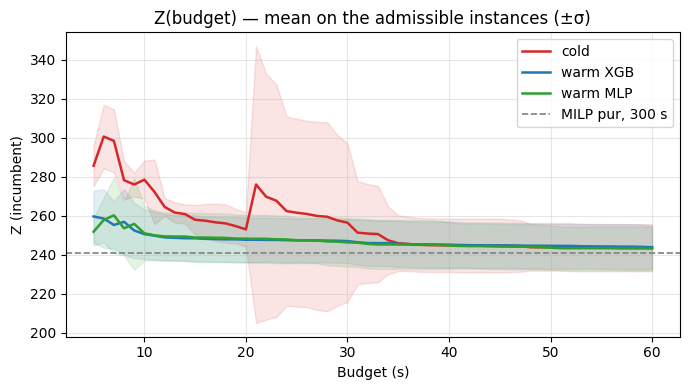

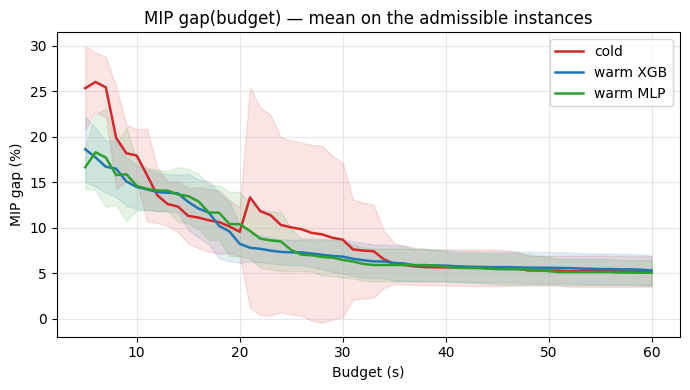

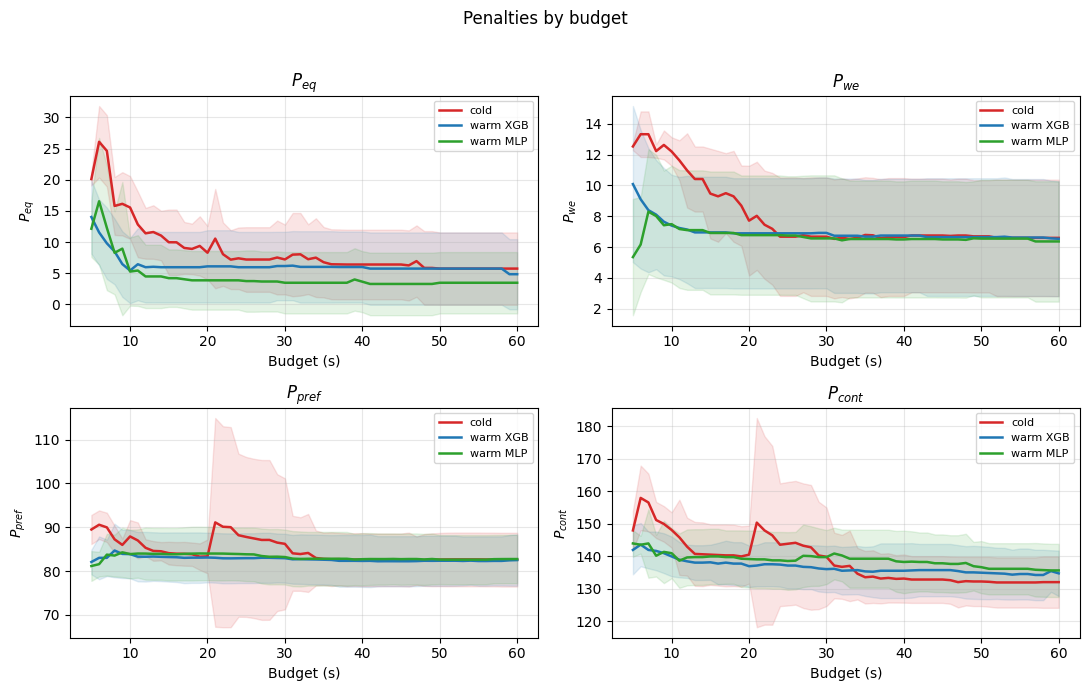

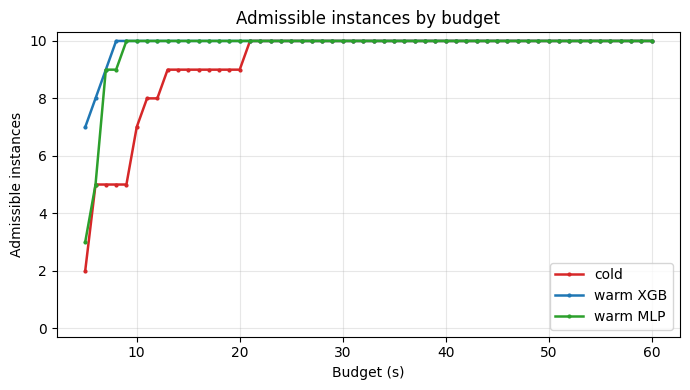

In [22]:
# ===================== Trajectory run (cached) =====================
TRAJ_PATH = f'{RESULTS_DIR}/trajectories_5_60.npz'
NAMES = ['cold', 'xgb', 'mlp']

if not FORCE_RERUN and os.path.exists(TRAJ_PATH):
    res = load_results(TRAJ_PATH, NAMES)
    print(f"Trajectories uploaded from the cache : {TRAJ_PATH}")
else:
    t0 = time.time()
    res = {
        'cold': aggregate_trajectories(insts_test, warm=False, tag='cold', time_limit=60),
        'xgb':  aggregate_trajectories(insts_test, warm=True, ml_model=xgb_model,
                                       scaler=None, model_type='xgb', tag='warm XGB', time_limit=60),
        'mlp':  aggregate_trajectories(insts_test, warm=True, ml_model=mlp_model,
                                       scaler=nn_scaler, model_type='nn', tag='warm MLP', time_limit=60),
    }
    save_results(TRAJ_PATH, **res)
    print(f"({(time.time()-t0)/60:.1f} min)")

series = [('cold', res['cold'], 'tab:red'),
          ('warm XGB', res['xgb'], 'tab:blue'),
          ('warm MLP', res['mlp'], 'tab:green')]

# Reference line "pure MILP, 300 s" derived from Table 4 (when available)
ref_Z = float(np.nanmean([r['Z'] for r in milp_rows])) if 'milp_rows' in globals() else None

fig = plot_metric(series, 'Z', 'Z (incumbent)',
                  'Z(budget) — mean on the admissible instances (±σ)')
if ref_Z is not None:
    fig.axes[0].axhline(ref_Z, ls='--', c='gray', lw=1.2, label='MILP pur, 300 s')
    fig.axes[0].legend()
fig.savefig(f'{RESULTS_DIR}/fig1a_Z.pdf', bbox_inches='tight')

fig = plot_metric(series, 'gap', 'MIP gap (%)',
                  'MIP gap(budget) — mean on the admissible instances', scale=100.0)
fig.savefig(f'{RESULTS_DIR}/fig1c_gap.pdf', bbox_inches='tight')

fig = plot_penalties(series)
fig.savefig(f'{RESULTS_DIR}/fig1b_penalites.pdf', bbox_inches='tight')

fig = plot_n_solved(series, n_total=len(insts_test))
fig.savefig(f'{RESULTS_DIR}/fig1d_admissibles.pdf', bbox_inches='tight')
plt.show()


## §8 — Experiment 4: SHAP analysis (local explainability, E3)

Which descriptors drive the warm-start model, and how? TreeSHAP is exact on gradient-boosted trees,
so the attribution is deterministic rather than approximate. Three outputs: global importance,
per-feature contribution distributions, and dependence plots for the four dominant descriptors.

Reads `X_test` and `feature_cols` from §5. Runtime ~5 min.

Computing SHAP values...
Shape SHAP values: (10000, 25)


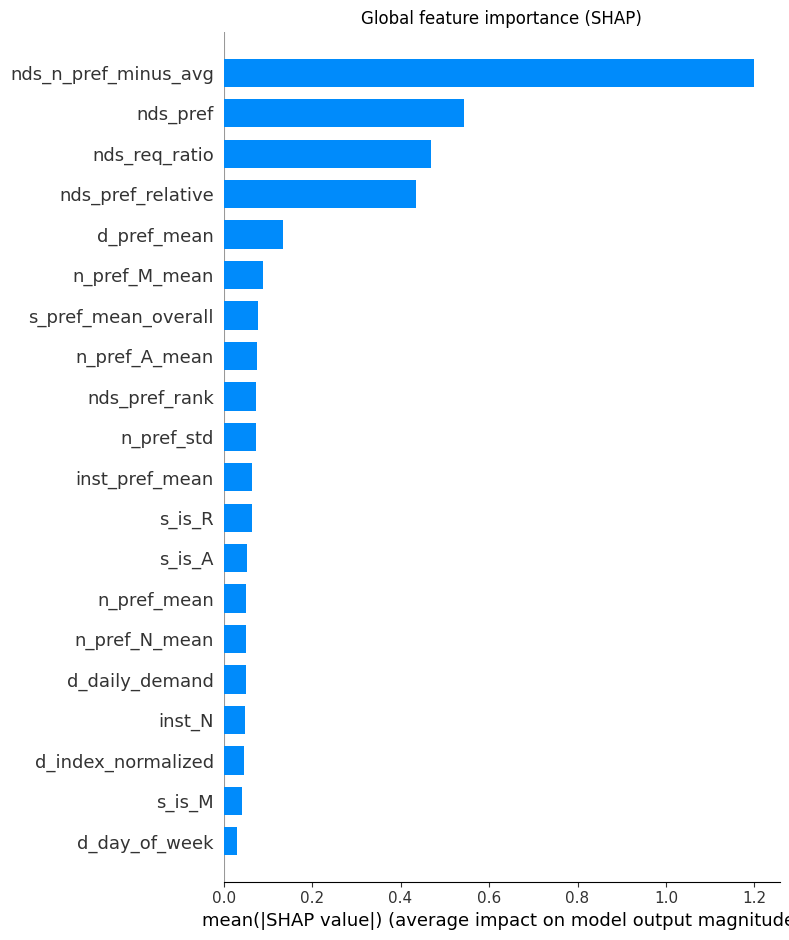

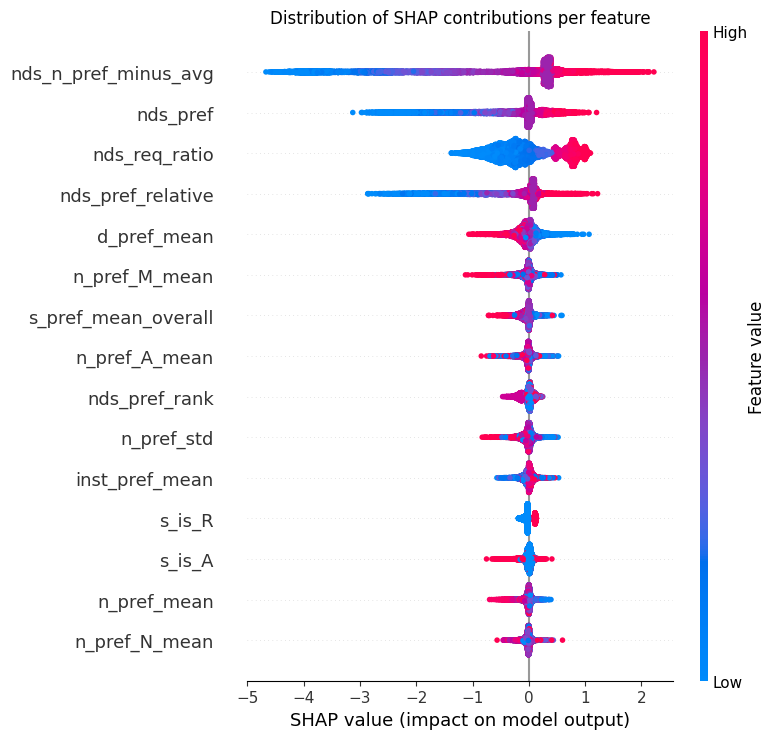

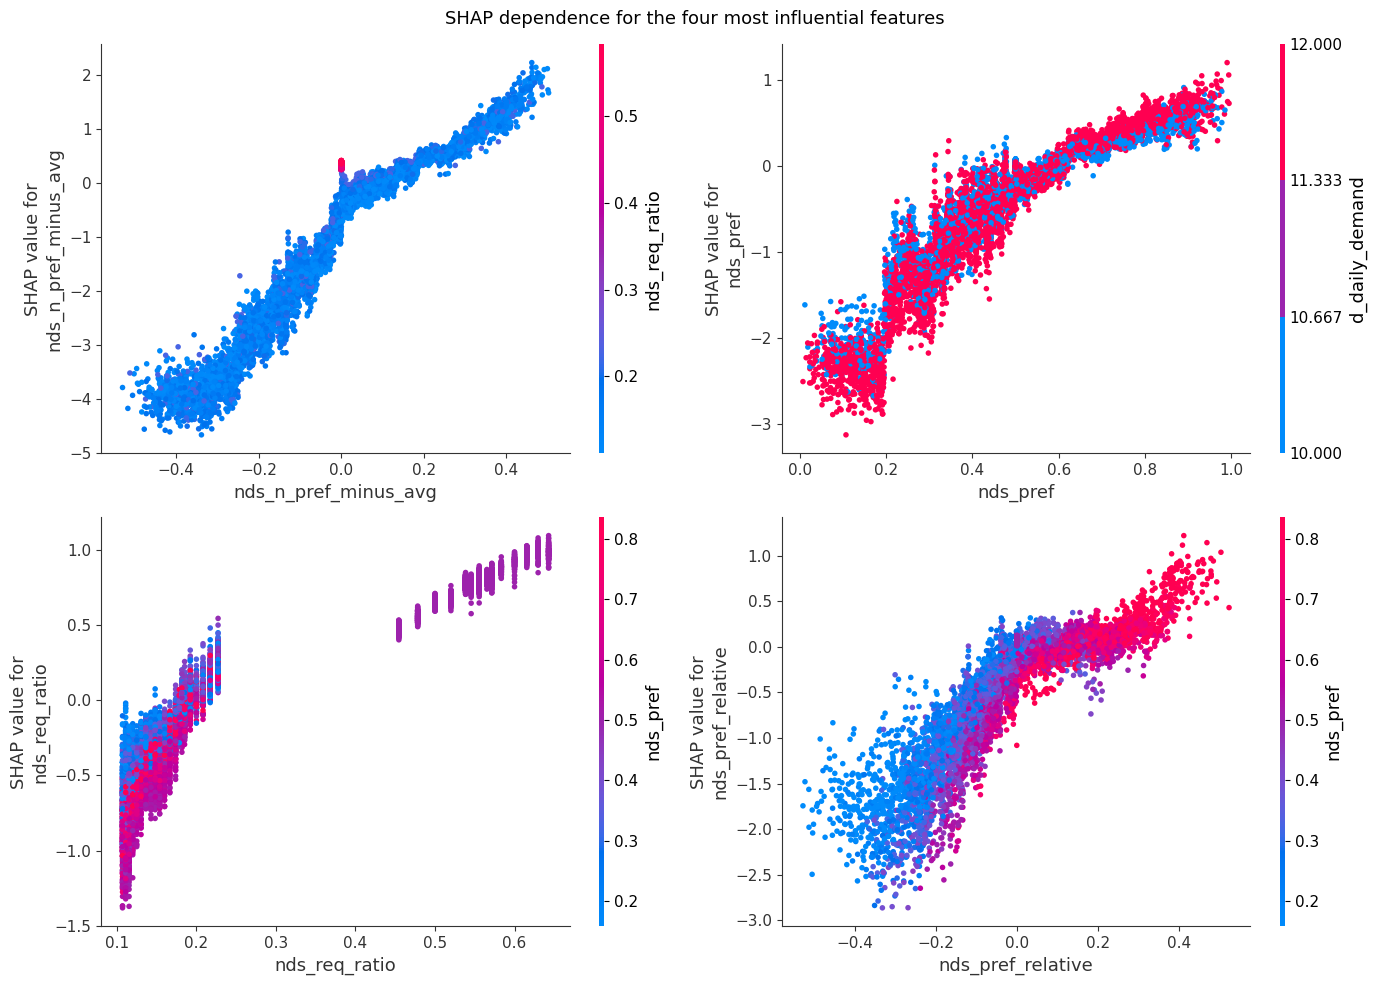


=== Top 15 features by SHAP importance ===
                 feature  mean_abs_shap
0   nds_n_pref_minus_avg         1.1978
1               nds_pref         0.5437
2          nds_req_ratio         0.4681
3      nds_pref_relative         0.4346
4            d_pref_mean         0.1349
5          n_pref_M_mean         0.0891
6    s_pref_mean_overall         0.0788
7          n_pref_A_mean         0.0744
8          nds_pref_rank         0.0736
9             n_pref_std         0.0722
10        inst_pref_mean         0.0640
11                s_is_R         0.0635
12                s_is_A         0.0521
13           n_pref_mean         0.0513
14         n_pref_N_mean         0.0505

✓ SHAP analysis complete. Files saved to /content/drive/MyDrive/NSP_results/hybrid_dataset/


In [23]:
# ====================================================================
# SHAP analysis of the XGBoost warm-start model
# ====================================================================
%pip install -q shap

import shap
import matplotlib.pyplot as plt

# Load model and data
xgb_model = joblib.load(f'{DATASET_DIR}/xgb_model.pkl')
feature_cols = joblib.load(f'{DATASET_DIR}/feature_cols.pkl')

# Subsample the test set to speed SHAP up (~10,000 rows is plenty)
n_sample = min(10000, len(X_test))
sample_idx = np.random.default_rng(42).choice(len(X_test), n_sample, replace=False)
X_shap = X_test[sample_idx]

# === 1. Compute SHAP values ===
print("Computing SHAP values...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)
print(f"Shape SHAP values: {shap_values.shape}")

# === 2. Global feature importance ===
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap, feature_names=feature_cols,
    plot_type='bar', show=False, max_display=20,
)
plt.title("Global feature importance (SHAP)", fontsize=12)
plt.tight_layout()
plt.savefig(f'{DATASET_DIR}/shap_importance_bar.pdf', bbox_inches='tight', dpi=150)
plt.show()

# === 3. Summary plot (direction of the impact) ===
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap, feature_names=feature_cols,
    show=False, max_display=15,
)
plt.title("Distribution of SHAP contributions per feature", fontsize=12)
plt.tight_layout()
plt.savefig(f'{DATASET_DIR}/shap_summary.pdf', bbox_inches='tight', dpi=150)
plt.show()

# === 4. Dependence plots for the top features ===
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(mean_abs_shap)[::-1][:4]
top_features_names = [feature_cols[i] for i in top_features_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, idx in zip(axes.flat, top_features_idx):
    shap.dependence_plot(
        idx, shap_values, X_shap, feature_names=feature_cols,
        ax=ax, show=False, interaction_index='auto',
    )
plt.suptitle("SHAP dependence for the four most influential features", fontsize=13)
plt.tight_layout()
plt.savefig(f'{DATASET_DIR}/shap_dependence.pdf', bbox_inches='tight', dpi=150)
plt.show()

# === 5. Table of the top features ===
df_importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("\n=== Top 15 features by SHAP importance ===")
print(df_importance.head(15).round(4))
df_importance.to_csv(f'{DATASET_DIR}/shap_importance.csv', index=False)

print(f"\n✓ SHAP analysis complete. Files saved to {DATASET_DIR}/")

## §9 — Experiment 5: Pareto fronts (global explainability, E1)

The objective weights are not a hidden setting: each trade-off is mapped by re-solving the model
while varying one weight at a time. Three fronts — fairness vs preferences, fairness vs continuity,
preferences vs continuity — justify the operating point (1, 1, 2, 0.5) graphically instead of
postulating it.

Reference instance, 90 s budget, 2% MIPGap, 16 solves. Runtime ~40 min.

In [24]:
# ====================================================================
# Pareto fronts (weight calibration)
# ====================================================================

def compute_pareto_front(
    inst, varying_weight: str, varying_values: list,
    fixed_weights: dict, time_limit: int = 90, mip_gap: float = 0.02,
) -> pd.DataFrame:
    """Pareto front: vary a single weight, keep the others fixed."""
    records = []
    for val in varying_values:
        weights = dict(fixed_weights)
        weights[varying_weight] = val
        print(f"\n--- α_{varying_weight} = {val} ---")
        result = build_and_solve_milp(
            inst, weights=weights,
            time_limit=time_limit, mip_gap=mip_gap, verbose=0,
        )
        if result['obj'] is not None:
            metrics = compute_trust_metrics(result, inst)
            records.append({
                f'alpha_{varying_weight}': val,
                **{k: result['penalties'][k] for k in ['P_eq', 'P_we', 'P_pref', 'P_cont']},
                'JFI_charges': metrics['JFI_charges'],
                'pref_mean': metrics['pref_mean'],
                'solve_time': result['solve_time'],
                'gap': result['gap'],
            })
            print(f"  P_eq={result['penalties']['P_eq']:.2f}, "
                  f"P_pref={result['penalties']['P_pref']:.2f}, "
                  f"P_cont={result['penalties']['P_cont']:.2f}, "
                  f"gap={result['gap']*100:.1f}%")
    return pd.DataFrame(records)

def plot_pareto_front(df_pareto, varying_weight, y_penalty,
                      x_penalty='P_eq', title_suffix="", savepath=None):
    """Plot the Pareto front."""
    alpha_col = f'alpha_{varying_weight}'
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # --- Left subplot: the front itself (x_penalty vs y_penalty) ---
    axes[0].plot(df_pareto[x_penalty], df_pareto[y_penalty],
                 'o-', color='navy', markersize=8, linewidth=1.5,
                 label='Pareto-optimal solutions')
    for _, row in df_pareto.iterrows():
        axes[0].annotate(f"α={row[alpha_col]}",
                         (row[x_penalty], row[y_penalty]),
                         textcoords="offset points", xytext=(8, 5),
                         fontsize=9, color='#444')
    axes[0].set_xlabel(f"${x_penalty}$", fontsize=11)
    axes[0].set_ylabel(f"${y_penalty}$", fontsize=11)
    axes[0].set_title(f"Pareto front: {x_penalty} vs {y_penalty}{title_suffix}", fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='best', fontsize=9)

    # --- Right subplot: evolution vs weight (TWIN y axes) ---
    ax2 = axes[1]
    ax2.set_xscale('log')
    line1, = ax2.plot(df_pareto[alpha_col], df_pareto[x_penalty],
                      'o-', color='crimson', label=x_penalty)
    ax2.set_xlabel(rf"$\alpha_{{{varying_weight}}}$", fontsize=11)
    ax2.set_ylabel(x_penalty, color='crimson', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='crimson')

    ax2_twin = ax2.twinx()
    line2, = ax2_twin.plot(df_pareto[alpha_col], df_pareto[y_penalty],
                           's-', color='navy', label=y_penalty)
    ax2_twin.set_ylabel(y_penalty, color='navy', fontsize=11)
    ax2_twin.tick_params(axis='y', labelcolor='navy')

    # COMBINED legend for both axes (otherwise only one of them shows)
    ax2.legend(handles=[line1, line2], loc='best', fontsize=10)

    ax2.set_title("Evolution as a function of the weight", fontsize=12)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=150)
    plt.show()


========== FRONT 1: fairness vs preferences ==========
reloaded from cache


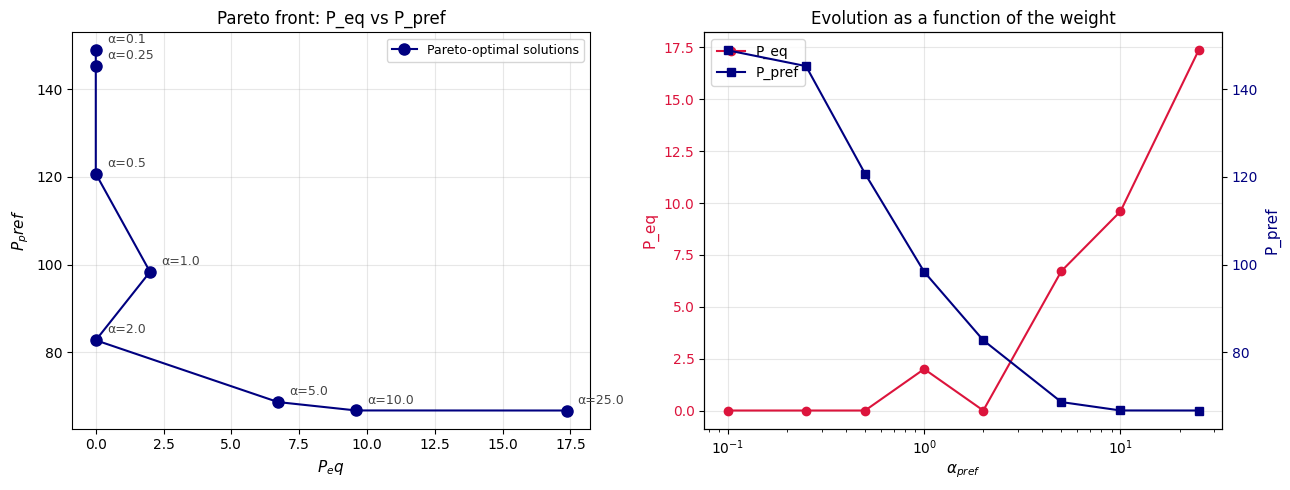


========== FRONTS 2 and 3: varying alpha_cont ==========
reloaded from cache


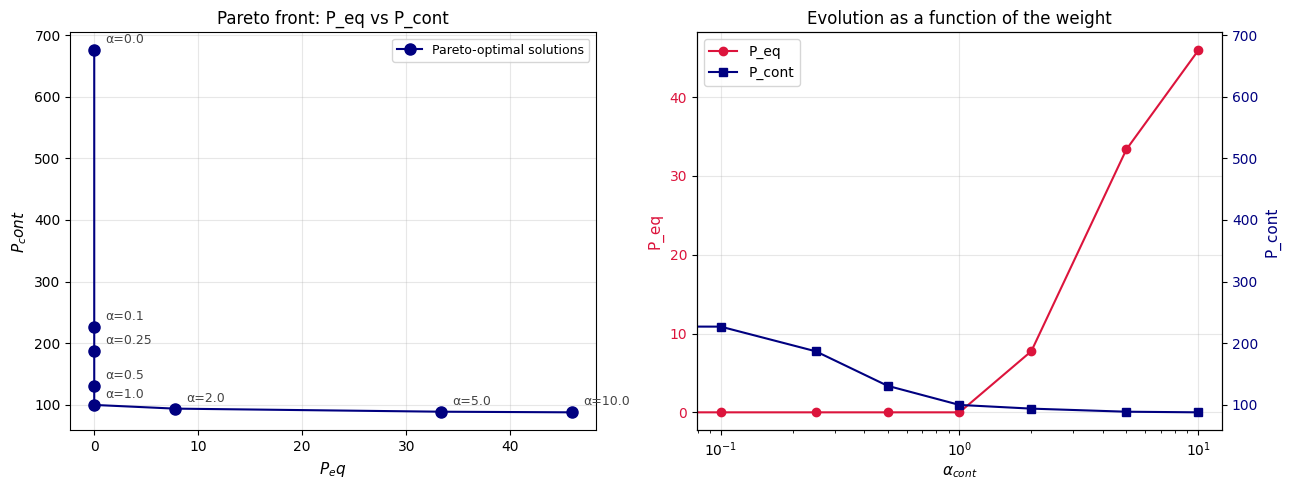

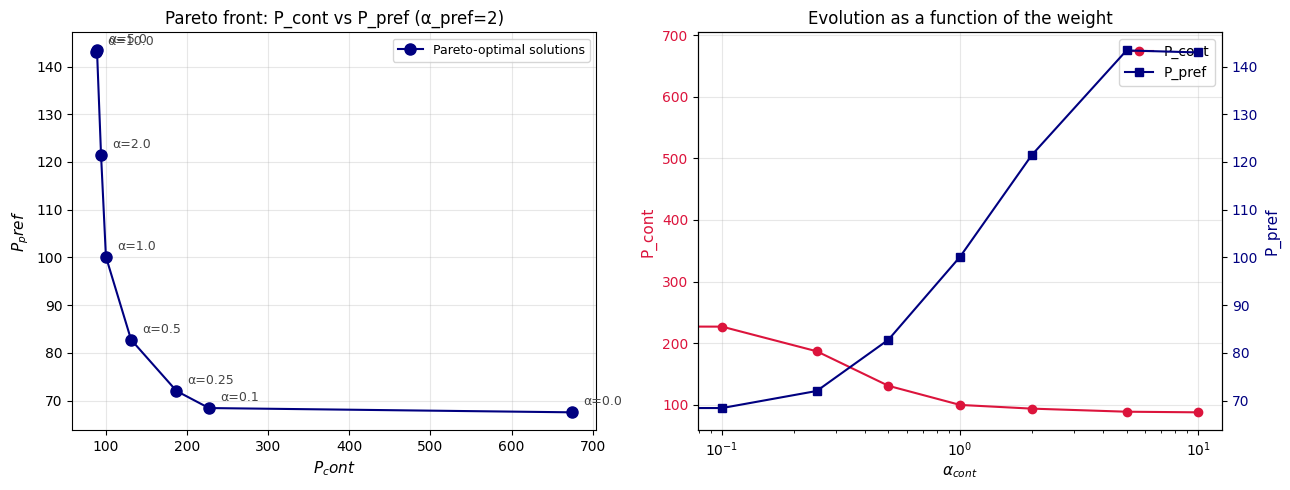


✓ Fronts saved to /content/drive/MyDrive/NSP_results/


In [25]:
# === Front 1: fairness vs preferences ===
print("\n========== FRONT 1: fairness vs preferences ==========")
PARETO_PREF_CSV = f'{RESULTS_DIR}/pareto_eq_vs_pref.csv'
if not FORCE_RERUN and os.path.exists(PARETO_PREF_CSV):
    df_pareto_pref = pd.read_csv(PARETO_PREF_CSV)
    print('reloaded from cache')
else:
    df_pareto_pref = compute_pareto_front(
    inst, varying_weight='pref',
    varying_values=[0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 25.0],
    fixed_weights={'eq': 1.0, 'we': 1.0, 'pref': 1.0, 'cont': 0.5},
        time_limit=90, mip_gap=0.02)
    df_pareto_pref.to_csv(f'{RESULTS_DIR}/pareto_eq_vs_pref.csv', index=False)
plot_pareto_front(df_pareto_pref, 'pref', y_penalty='P_pref',
                  savepath=f'{RESULTS_DIR}/pareto_eq_vs_pref.pdf')

# === Fronts 2 and 3: varying alpha_cont (with alpha_pref = 2 fixed) ===
print("\n========== FRONTS 2 and 3: varying alpha_cont ==========")
PARETO_CONT_CSV = f'{RESULTS_DIR}/pareto_cont_variation.csv'
if not FORCE_RERUN and os.path.exists(PARETO_CONT_CSV):
    df_pareto_cont = pd.read_csv(PARETO_CONT_CSV)
    print('reloaded from cache')
else:
    df_pareto_cont = compute_pareto_front(
    inst, varying_weight='cont',
    varying_values=[0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0],
    fixed_weights={'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5},
        time_limit=90, mip_gap=0.02)
    df_pareto_cont.to_csv(f'{RESULTS_DIR}/pareto_cont_variation.csv', index=False)

# Front 2: fairness vs continuity
plot_pareto_front(df_pareto_cont, 'cont', y_penalty='P_cont',
                  savepath=f'{RESULTS_DIR}/pareto_eq_vs_cont.pdf')
# Front 3: preferences vs continuity (same DataFrame)
plot_pareto_front(df_pareto_cont, 'cont',
                  x_penalty='P_cont', y_penalty='P_pref',
                  title_suffix=" (α_pref=2)",
                  savepath=f'{RESULTS_DIR}/pareto_pref_vs_cont.pdf')

print(f"\n✓ Fronts saved to {RESULTS_DIR}/")

## §10 — Experiment 6: robustness to disruptions (P1–P3)

Three disruption scenarios applied to the nominal solution, 10 random draws each:

- **P1** — one nurse absent for one day
- **P2** — demand peak (+1 required nurse on one shift, three consecutive days)
- **P3** — outbreak: three nurses absent for two consecutive days

Repair minimises deviation from the nominal solution (Hamming distance, `lambda_dist`), so what is
measured is the **organisational cost of reacting**, not just feasibility: Hamming distance, relative
objective degradation, repair time. Both approaches are evaluated: the MILP repairs by re-solving a
constrained model, the SA by re-annealing from the disrupted solution.

Runtime ~1.5 h (dominated by the SA repairs, ~157 s each).

In [26]:
# ---- Reference solutions used by the disruption experiments ----------------
# result_ref : nominal MILP solution (x0 in the repair objective)
# result_sa  : nominal SA solution, same instance, seed 42
REF_MILP_PKL = f'{RESULTS_DIR}/result_ref_milp.pkl'
REF_SA_PKL   = f'{RESULTS_DIR}/result_ref_sa.pkl'

if not FORCE_RERUN and os.path.exists(REF_MILP_PKL):
    with open(REF_MILP_PKL, 'rb') as fh:
        result_ref = pickle.load(fh)
    print('nominal MILP solution reloaded from cache')
else:
    result_ref = build_and_solve_milp(inst, weights=WEIGHTS,
                                      time_limit=300, mip_gap=0.01, verbose=0)
    with open(REF_MILP_PKL, 'wb') as fh:
        pickle.dump(result_ref, fh)

if not FORCE_RERUN and os.path.exists(REF_SA_PKL):
    with open(REF_SA_PKL, 'rb') as fh:
        result_sa = pickle.load(fh)
    print('nominal SA solution reloaded from cache')
else:
    result_sa = simulated_annealing(inst, weights=WEIGHTS, seed=42, verbose=False)
    with open(REF_SA_PKL, 'wb') as fh:
        pickle.dump(result_sa, fh)

print(f"nominal MILP Z = {sum(WEIGHTS[k[2:]] * v for k, v in result_ref['penalties'].items()):.2f}"
      f" | nominal SA energy = {result_sa['best_energy']:.2f}")


nominal MILP Z = 231.61 | nominal SA energy = 246.51


In [27]:
# ====================================================================
# Robustness evaluation
# ====================================================================

def repair_schedule(
    inst: NSPInstance, x0_values: dict,
    forbidden_nurses_days: list = None,
    extra_req: dict = None,
    weights: dict = None, lambda_dist: float = 10.0,
    time_limit: int = 120, mip_gap: float = 0.02, verbose: int = 0,
) -> dict:
    """Repair a schedule after a disruption, minimising the Hamming distance."""
    if weights is None:
        weights = {'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5}
    if forbidden_nurses_days is None:
        forbidden_nurses_days = []
    if extra_req is None:
        extra_req = {}

    m = gp.Model("NSP_repair", env=GRB_ENV)
    m.Params.OutputFlag = verbose
    m.Params.TimeLimit = time_limit
    m.Params.MIPGap = mip_gap

    x = m.addVars(
        [(n, d, s) for n in range(inst.N) for d in range(inst.D) for s in inst.shifts_all],
        vtype=GRB.BINARY, name="x"
    )

    # Disruptions
    for n, d in forbidden_nurses_days:
        for s in inst.shifts:
            m.addConstr(x[n, d, s] == 0)
        m.addConstr(x[n, d, 'R'] == 1)

    # Hard constraints (same as the nominal MILP, with extra_req added to H2)
    m.addConstrs((quicksum(x[n, d, s] for s in inst.shifts_all) == 1
                  for n in range(inst.N) for d in range(inst.D)), name="H1")
    for d in range(inst.D):
        for s in inst.shifts:
            req = inst.Req[d, s] + extra_req.get((d, s), 0)
            m.addConstr(quicksum(x[n, d, s] for n in range(inst.N)) >= req)
    m.addConstrs((x[n, d, 'N'] + x[n, d+1, 'M'] <= 1
                  for n in range(inst.N) for d in range(inst.D - 1)), name="H3")
    m.addConstrs((quicksum(x[n, d+k, s]
                           for k in range(inst.W_max + 1) for s in inst.shifts) <= inst.W_max
                  for n in range(inst.N)
                  for d in range(inst.D - inst.W_max)), name="H4")
    m.addConstrs((quicksum(x[n, d, 'N'] for d in range(inst.D)) <= inst.N_max
                  for n in range(inst.N)), name="H5")

    weekend_pairs = inst.weekend_pairs
    f = m.addVars([(n, w) for n in range(inst.N) for w in range(len(weekend_pairs))],
                  vtype=GRB.BINARY, name="f")
    for n in range(inst.N):
        for w, (sat, sun) in enumerate(weekend_pairs):
            m.addConstr(f[n, w] <= x[n, sat, 'R'])
            m.addConstr(f[n, w] <= x[n, sun, 'R'])
        m.addConstr(quicksum(f[n, w] for w in range(len(weekend_pairs))) >= inst.WE_min)

    # Soft penalties
    P_pref = quicksum((1 - inst.pref[n, d, s]) * x[n, d, s]
                      for n in range(inst.N) for d in range(inst.D) for s in inst.shifts)
    c = m.addVars([(n, d) for n in range(inst.N) for d in range(inst.D - 1)],
                  vtype=GRB.BINARY, name="c")
    for n in range(inst.N):
        for d in range(inst.D - 1):
            for s in inst.shifts:
                m.addConstr(c[n, d] >= x[n, d, s] - x[n, d+1, s])
    P_cont = quicksum(c[n, d] for n in range(inst.N) for d in range(inst.D - 1))

    W = {n: quicksum(x[n, d, s] for d in range(inst.D) for s in inst.shifts)
         for n in range(inst.N)}
    W_bar = quicksum(W[n] for n in range(inst.N)) / inst.N
    dp = m.addVars(range(inst.N), lb=0, name="dp")
    dm = m.addVars(range(inst.N), lb=0, name="dm")
    for n in range(inst.N):
        m.addConstr(W[n] - W_bar == dp[n] - dm[n])
    P_eq = quicksum(dp[n] + dm[n] for n in range(inst.N))

    WE_work = {n: quicksum(x[n, d, s] for d in inst.weekend_days for s in inst.shifts)
               for n in range(inst.N)}
    total_we = sum(inst.Req[d, s] for d in inst.weekend_days for s in inst.shifts)
    WE_target = total_we / inst.N
    gp_var = m.addVars(range(inst.N), lb=0, name="gp")
    gm_var = m.addVars(range(inst.N), lb=0, name="gm")
    for n in range(inst.N):
        m.addConstr(WE_work[n] - WE_target == gp_var[n] - gm_var[n])
    P_we = quicksum(gp_var[n] + gm_var[n] for n in range(inst.N))

    # Linearised Hamming distance (x0 fixed -> |x-x0| = x if x0=0, 1-x if x0=1)
    hamming = quicksum(
        (x[n, d, s] if x0_values.get((n, d, s), 0) == 0 else (1 - x[n, d, s]))
        for n in range(inst.N) for d in range(inst.D) for s in inst.shifts_all
    )

    m.setObjective(
        weights['eq'] * P_eq + weights['we'] * P_we
        + weights['pref'] * P_pref + weights['cont'] * P_cont
        + lambda_dist * hamming,
        GRB.MINIMIZE
    )
    m.optimize()

    result = {'status': m.Status, 'solve_time': m.Runtime}
    if m.SolCount > 0:
        p_eq = sum(dp[n].X + dm[n].X for n in range(inst.N))
        p_we = sum(gp_var[n].X + gm_var[n].X for n in range(inst.N))
        p_pref = sum((1 - inst.pref[n, d, s]) * x[n, d, s].X
                     for n in range(inst.N) for d in range(inst.D) for s in inst.shifts)
        p_cont = sum(c[n, d].X for n in range(inst.N) for d in range(inst.D - 1))
        ham = sum(abs(x[n, d, s].X - x0_values.get((n, d, s), 0))
                  for n in range(inst.N) for d in range(inst.D) for s in inst.shifts_all)
        Z_rep = (weights['eq']*p_eq + weights['we']*p_we
                 + weights['pref']*p_pref + weights['cont']*p_cont)
        result.update({
            'obj': m.ObjVal, 'gap': m.MIPGap,
            'hamming': ham, 'Z_repaired': Z_rep,
            'penalties': {'P_eq': p_eq, 'P_we': p_we, 'P_pref': p_pref, 'P_cont': p_cont},
            'schedule': extract_schedule(x, inst),
        })
    return result


def scenario_P1(result0, inst, seed=0):
    rng = random.Random(seed)
    df0 = result0['schedule']
    working = [(n, d) for n in range(inst.N) for d in range(inst.D) if df0.iloc[n, d] != 'R']
    n_abs, d_abs = rng.choice(working)
    return {'description': f"Absence of nurse {n_abs} day {d_abs}",
            'forbidden_nurses_days': [(n_abs, d_abs)]}


def scenario_P2(result0, inst, seed=0, duration=3):
    rng = random.Random(seed)
    d_start = rng.randint(0, inst.D - duration)
    s_peak = rng.choice(inst.shifts)
    return {'description': f"Demand peak {s_peak} days {d_start}-{d_start+duration-1}",
            'extra_req': {(d_start + k, s_peak): 1 for k in range(duration)}}


def scenario_P3(result0, inst, seed=0, n_absent=3, duration=2):
    rng = random.Random(seed)
    d_start = rng.randint(0, inst.D - duration)
    df0 = result0['schedule']
    candidates = [n for n in range(inst.N)
                  if any(df0.iloc[n, d_start + k] != 'R' for k in range(duration))]
    absent = rng.sample(candidates, min(n_absent, len(candidates)))
    forbidden = [(n, d_start + k) for n in absent for k in range(duration)]
    return {'description': f"Outbreak, nurses {absent} days {d_start}-{d_start+duration-1}",
            'forbidden_nurses_days': forbidden}


def analyze_perturbation(result0, inst, perturbation, weights=None):
    if weights is None:
        weights = {'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5}
    forbidden = perturbation.get('forbidden_nurses_days', [])
    extra_req = perturbation.get('extra_req', {})
    x0 = result0['x_values']

    # Violations of the nominal solution under the disruption
    violations_H2 = 0
    for d in range(inst.D):
        for s in inst.shifts:
            effective = sum(x0[(n, d, s)] for n in range(inst.N)
                            if (n, d) not in forbidden)
            req = inst.Req[d, s] + extra_req.get((d, s), 0)
            if effective < req:
                violations_H2 += int(req - effective)

    repaired = repair_schedule(
        inst, x0_values=x0,
        forbidden_nurses_days=forbidden, extra_req=extra_req,
        weights=weights, lambda_dist=10.0, time_limit=120, verbose=0,
    )

    if 'schedule' not in repaired:
        return {'description': perturbation['description'], 'violations_H2': violations_H2,
                'infeasible': True, 'repair_time': repaired['solve_time']}

    Z_nom = (weights['eq']*result0['penalties']['P_eq']
             + weights['we']*result0['penalties']['P_we']
             + weights['pref']*result0['penalties']['P_pref']
             + weights['cont']*result0['penalties']['P_cont'])
    delta_Z = (repaired['Z_repaired'] - Z_nom) / Z_nom if Z_nom > 0 else 0

    return {
        'description': perturbation['description'],
        'violations_H2': violations_H2,
        'hamming_distance': repaired['hamming'],
        'delta_Z_relative': delta_Z,
        'repair_time': repaired['solve_time'],
        'infeasible': False,
    }


def evaluate_robustness(result0, inst, n_trials=10, weights=None):
    records = []
    scenarios = {'P1': scenario_P1, 'P2': scenario_P2, 'P3': scenario_P3}
    for name, func in scenarios.items():
        print(f"\n=== Scenario {name} ===")
        for trial in range(n_trials):
            pert = func(result0, inst, seed=trial)
            an = analyze_perturbation(result0, inst, pert, weights)
            rec = {'scenario': name, 'trial': trial,
                   'description': an['description'],
                   'violations_H2': an['violations_H2'],
                   'infeasible': an.get('infeasible', False),
                   'repair_time_s': an['repair_time']}
            if not an.get('infeasible', False):
                rec['hamming'] = an['hamming_distance']
                rec['delta_Z_pct'] = an['delta_Z_relative'] * 100
                print(f"  Trial {trial}: viol={an['violations_H2']}, "
                      f"hamming={an['hamming_distance']:.0f}, "
                      f"ΔZ={an['delta_Z_relative']*100:+.2f}%, "
                      f"time={an['repair_time']:.1f}s")
            else:
                rec['hamming'] = None
                rec['delta_Z_pct'] = None
                print(f"  Trial {trial}: INFEASIBLE")
            records.append(rec)
    return pd.DataFrame(records)


# Run
df_robustness = evaluate_robustness(
    result_ref, inst, n_trials=10,
    weights={'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5},
)
df_robustness.to_csv(f'{RESULTS_DIR}/robustness.csv', index=False)

# Summary
summary = df_robustness.groupby('scenario').agg(
    viol_mean=('violations_H2', 'mean'),
    viol_std=('violations_H2', 'std'),
    hamming_mean=('hamming', 'mean'),
    hamming_std=('hamming', 'std'),
    deltaZ_mean=('delta_Z_pct', 'mean'),
    deltaZ_std=('delta_Z_pct', 'std'),
    time_mean=('repair_time_s', 'mean'),
).round(2)
print("\n=== Summary ===")
print(summary)
summary.to_csv(f'{RESULTS_DIR}/robustness_summary.csv')

print(f"\n✓ Robustness results saved to {RESULTS_DIR}/")


=== Scenario P1 ===
  Trial 0: viol=1, hamming=10, ΔZ=+1.88%, time=0.4s
  Trial 1: viol=1, hamming=20, ΔZ=+1.96%, time=0.4s
  Trial 2: viol=1, hamming=6, ΔZ=+0.67%, time=0.7s
  Trial 3: viol=1, hamming=22, ΔZ=+0.77%, time=0.7s
  Trial 4: viol=1, hamming=22, ΔZ=+1.26%, time=0.4s
  Trial 5: viol=1, hamming=10, ΔZ=+1.66%, time=0.8s
  Trial 6: viol=1, hamming=12, ΔZ=+2.26%, time=0.7s
  Trial 7: viol=0, hamming=18, ΔZ=+2.07%, time=0.3s
  Trial 8: viol=0, hamming=8, ΔZ=+0.96%, time=0.3s
  Trial 9: viol=1, hamming=16, ΔZ=+1.04%, time=0.4s

=== Scenario P2 ===
  Trial 0: viol=2, hamming=26, ΔZ=+3.32%, time=0.6s
  Trial 1: viol=3, hamming=38, ΔZ=+3.37%, time=0.7s
  Trial 2: viol=1, hamming=22, ΔZ=+1.94%, time=0.6s
  Trial 3: viol=2, hamming=30, ΔZ=+2.02%, time=0.9s
  Trial 4: viol=2, hamming=28, ΔZ=+1.46%, time=0.8s
  Trial 5: viol=3, hamming=32, ΔZ=+1.46%, time=0.8s
  Trial 6: viol=3, hamming=14, ΔZ=+3.26%, time=0.7s
  Trial 7: viol=2, hamming=20, ΔZ=+2.63%, time=0.4s
  Trial 8: viol=2, hammi

In [28]:
def repair_schedule_sa(
    inst: NSPInstance,
    arr0: np.ndarray,
    forbidden_nurses_days: list = None,
    extra_req_dict: dict = None,
    weights: dict = None,
    lambda_hard: float = 1000.0,
    lambda_dist: float = 5.0,
    T_0: float = 10.0,
    T_min: float = 0.01,
    beta: float = 0.95,
    L: int = 500,
    seed: int = 42,
) -> dict:
    """
    SA-based repair of a disrupted solution.
    Starts from arr0 and minimises energy + lambda_dist * hamming(arr, arr0).

    Note: "extra_req" and "forbidden" are injected into count_hard_violations
    through a temporarily modified instance.
    """
    if weights is None:
        weights = {'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5}
    if forbidden_nurses_days is None:
        forbidden_nurses_days = []
    if extra_req_dict is None:
        extra_req_dict = {}

    SHIFT_R = 3

    # Build a modified copy of the instance carrying extra_req
    Req_modified = dict(inst.Req)
    for (d, s), extra in extra_req_dict.items():
        Req_modified[(d, s)] = inst.Req[d, s] + extra

    inst_modified = NSPInstance(
        N=inst.N, D=inst.D,
        Req=Req_modified, pref=inst.pref,
        W_max=inst.W_max, N_max=inst.N_max, WE_min=inst.WE_min,
        weekend_days=inst.weekend_days, shifts=inst.shifts,
    )

    # Force the absences into the initial solution
    arr_init = arr0.copy()
    for (n, d) in forbidden_nurses_days:
        arr_init[n, d] = SHIFT_R

    rng = np.random.default_rng(seed)

    def energy_with_distance(arr):
        e_base, soft, hard = compute_energy(arr, inst_modified, weights, lambda_hard)
        # Hamming distance: how many cells differ from arr0
        # Cells forced to R are excluded (they are not genuine "changes")
        forbidden_set = set(forbidden_nurses_days)
        ham = 0
        for n in range(inst.N):
            for d in range(inst.D):
                if (n, d) in forbidden_set:
                    continue
                if arr[n, d] != arr0[n, d]:
                    ham += 1
        return e_base + lambda_dist * ham, soft, hard, ham

    def neighbor_repair(arr):
        """Neighbour move that respects the forbidden cells."""
        arr_new = arr.copy()
        forbidden_set = set(forbidden_nurses_days)
        # Look for an editable cell
        for _ in range(50):  # tente max 50 fois
            n = rng.integers(0, inst.N)
            d = rng.integers(0, inst.D)
            if (n, d) in forbidden_set:
                continue
            current = arr[n, d]
            other_shifts = [s for s in range(4) if s != current]
            arr_new[n, d] = rng.choice(other_shifts)
            return arr_new
        return arr_new  # fallback

    s = arr_init.copy()
    e_current, soft_cur, hard_cur, ham_cur = energy_with_distance(s)
    s_best = s.copy()
    e_best = e_current
    soft_best = soft_cur
    hard_best = hard_cur
    ham_best = ham_cur

    T = T_0
    iteration = 0
    t_start = time.time()

    while T > T_min:
        for _ in range(L):
            s_new = neighbor_repair(s)
            e_new, soft_new, hard_new, ham_new = energy_with_distance(s_new)

            delta_E = e_new - e_current
            if delta_E <= 0 or rng.random() < math.exp(-delta_E / T):
                s = s_new
                e_current = e_new
                soft_cur = soft_new
                hard_cur = hard_new
                ham_cur = ham_new

                if e_current < e_best:
                    s_best = s.copy()
                    e_best = e_current
                    soft_best = soft_cur
                    hard_best = hard_cur
                    ham_best = ham_cur

            iteration += 1
        T *= beta

    elapsed = time.time() - t_start

    return {
        'arr': s_best,
        'soft': soft_best,
        'hard': hard_best,
        'hamming': ham_best,
        'elapsed': elapsed,
        'iterations': iteration,
    }


def analyze_perturbation_sa(result_sa, inst, perturbation, weights=None):
    """
    SA robustness analysis: apply the disruption, repair with SA,
    compare nominal vs repaired energy.
    """
    if weights is None:
        weights = {'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5}

    forbidden = perturbation.get('forbidden_nurses_days', [])
    extra_req = perturbation.get('extra_req', {})

    arr0 = result_sa['best_arr']

    # Violations under the disruption (before repair)
    violations_H2 = 0
    SHIFT_M, SHIFT_A, SHIFT_N = 0, 1, 2
    shift_to_int = {'M': SHIFT_M, 'A': SHIFT_A, 'N': SHIFT_N}
    forbidden_set = set(forbidden)
    for d in range(inst.D):
        for s_name in inst.shifts:
            s_int = shift_to_int[s_name]
            effective = sum(
                1 for n in range(inst.N)
                if arr0[n, d] == s_int and (n, d) not in forbidden_set
            )
            req = inst.Req[d, s_name] + extra_req.get((d, s_name), 0)
            if effective < req:
                violations_H2 += req - effective

    # Repair
    repaired = repair_schedule_sa(
        inst, arr0=arr0,
        forbidden_nurses_days=forbidden, extra_req_dict=extra_req,
        weights=weights,
        T_0=10.0, T_min=0.01, beta=0.95, L=500, seed=42,
    )

    # Energies used for the delta-Z computation
    Z_nominal = (weights['eq'] * result_sa['best_soft']['P_eq']
                 + weights['we'] * result_sa['best_soft']['P_we']
                 + weights['pref'] * result_sa['best_soft']['P_pref']
                 + weights['cont'] * result_sa['best_soft']['P_cont'])
    Z_repaired = (weights['eq'] * repaired['soft']['P_eq']
                  + weights['we'] * repaired['soft']['P_we']
                  + weights['pref'] * repaired['soft']['P_pref']
                  + weights['cont'] * repaired['soft']['P_cont'])
    delta_Z = (Z_repaired - Z_nominal) / Z_nominal if Z_nominal > 0 else 0

    return {
        'description': perturbation.get('description', ''),
        'violations_H2': violations_H2,
        'hamming_distance': repaired['hamming'],
        'final_violations': repaired['hard']['total'],
        'delta_Z_relative': delta_Z,
        'repair_time': repaired['elapsed'],
    }


def evaluate_robustness_sa(result_sa, inst, n_trials=10, weights=None):
    """Evaluate SA robustness across the three scenarios."""
    records = []
    scenarios = {'P1': scenario_P1, 'P2': scenario_P2, 'P3': scenario_P3}
    for name, func in scenarios.items():
        print(f"\n=== Scenario {name} ===")
        for trial in range(n_trials):
            # Reuse the MILP scenario_P1/P2/P3 helpers, which return
            # the same disruption format
            # scenario_P1 expects a "result0"-shaped dict carrying a schedule
            result0_compat = {'schedule': result_sa['best_schedule']}
            pert = func(result0_compat, inst, seed=trial)
            an = analyze_perturbation_sa(result_sa, inst, pert, weights)
            rec = {
                'scenario': name, 'trial': trial,
                'description': an['description'],
                'violations_H2': an['violations_H2'],
                'hamming': an['hamming_distance'],
                'final_violations': an['final_violations'],
                'delta_Z_pct': an['delta_Z_relative'] * 100,
                'repair_time_s': an['repair_time'],
            }
            records.append(rec)
            print(f"  Trial {trial}: viol_init={an['violations_H2']}, "
                  f"viol_final={an['final_violations']}, "
                  f"hamming={an['hamming_distance']}, "
                  f"ΔZ={an['delta_Z_relative']*100:+.2f}%, "
                  f"time={an['repair_time']:.1f}s")

            # Incremental checkpoint (so a crash does not lose the whole run)
            pd.DataFrame(records).to_csv(
                f'{RESULTS_DIR}/sa_robustness_partial.csv', index=False
            )

    return pd.DataFrame(records)

In [29]:
df_sa_robustness = evaluate_robustness_sa(
    result_sa, inst, n_trials=10,
    weights={'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5},
)
df_sa_robustness.to_csv(f'{RESULTS_DIR}/sa_robustness.csv', index=False)

# Summary
summary_sa = df_sa_robustness.groupby('scenario').agg(
    viol_init_mean=('violations_H2', 'mean'),
    viol_final_mean=('final_violations', 'mean'),
    hamming_mean=('hamming', 'mean'),
    hamming_std=('hamming', 'std'),
    deltaZ_mean=('delta_Z_pct', 'mean'),
    deltaZ_std=('delta_Z_pct', 'std'),
    time_mean=('repair_time_s', 'mean'),
).round(2)
print("\n=== SA summary ===")
print(summary_sa)


=== Scenario P1 ===
  Trial 0: viol_init=1, viol_final=0, hamming=17, ΔZ=+3.94%, time=178.9s
  Trial 1: viol_init=1, viol_final=0, hamming=5, ΔZ=+2.14%, time=177.1s
  Trial 2: viol_init=1, viol_final=0, hamming=7, ΔZ=+2.09%, time=179.3s
  Trial 3: viol_init=0, viol_final=0, hamming=0, ΔZ=+0.56%, time=178.9s
  Trial 4: viol_init=1, viol_final=0, hamming=12, ΔZ=+7.25%, time=176.7s
  Trial 5: viol_init=1, viol_final=0, hamming=7, ΔZ=+1.81%, time=173.4s
  Trial 6: viol_init=1, viol_final=0, hamming=10, ΔZ=+4.68%, time=173.7s
  Trial 7: viol_init=1, viol_final=0, hamming=40, ΔZ=+13.09%, time=180.7s
  Trial 8: viol_init=1, viol_final=0, hamming=22, ΔZ=+14.32%, time=174.6s
  Trial 9: viol_init=1, viol_final=0, hamming=8, ΔZ=+2.62%, time=175.6s

=== Scenario P2 ===
  Trial 0: viol_init=3, viol_final=0, hamming=21, ΔZ=+4.39%, time=175.3s
  Trial 1: viol_init=3, viol_final=0, hamming=34, ΔZ=+9.90%, time=176.0s
  Trial 2: viol_init=3, viol_final=0, hamming=11, ΔZ=+5.59%, time=175.8s
  Trial 3: v

## §11 — Experiment 7: stress test on N (D = 28 fixed)
Progressive reduction of the number of nurses on the reference instance (same Req, regenerated preferences with fixed seed), N = 24 → 17, MILP 300 s.

In [30]:
# ====================================================================
# CELL — Stress test : reduction of the number of nurses
# ====================================================================

def stress_test_N(
    base_inst: NSPInstance,
    N_values: list,
    weights: dict = None,
    time_limit: int = 180,
    mip_gap: float = 0.02,
) -> pd.DataFrame:

    if weights is None:
        weights = {'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5}

    records = []
    for N in N_values:
        print(f"\n========== N = {N} ==========")

        # Constructs an instance with N nurses (same Req, same parameters)
        rng = np.random.default_rng(seed=42)
        pref_N = {
            (n, d, s): float(rng.beta(2, 2))
            for n in range(N)
            for d in range(base_inst.D)
            for s in base_inst.shifts
        }
        inst_N = NSPInstance(
            N=N,
            D=base_inst.D,
            Req=base_inst.Req,
            pref=pref_N,
            W_max=base_inst.W_max,
            N_max=base_inst.N_max,
            WE_min=base_inst.WE_min,
            weekend_days=base_inst.weekend_days,
        )

        # Theoretical capacity
        max_capacity = N * base_inst.D * base_inst.W_max / (base_inst.W_max + 1)
        total_demand = sum(base_inst.Req[d, s]
                           for d in range(base_inst.D)
                           for s in base_inst.shifts)

        # Resolution
        result = build_and_solve_milp(
            inst_N, weights=weights,
            time_limit=time_limit, mip_gap=mip_gap, verbose=0,
        )

        # Status
        is_infeasible = (result['status'] in (GRB.INFEASIBLE, GRB.INF_OR_UNBD))
        no_solution = (result['obj'] is None)

        rec = {
            'N': N,
            'demand': total_demand,
            'capacity_max': round(max_capacity, 1),
            'ratio_demand_capacity': round(total_demand / max_capacity, 2),
            'infeasible': is_infeasible,
            'no_solution': no_solution,
            'solve_time': result['solve_time'],
        }

        if not no_solution:
            metrics = compute_trust_metrics(result, inst_N)
            rec.update({
                'obj': result['obj'],
                'gap': result['gap'],
                'P_eq': result['penalties']['P_eq'],
                'P_we': result['penalties']['P_we'],
                'P_pref': result['penalties']['P_pref'],
                'P_cont': result['penalties']['P_cont'],
                'JFI_charges': metrics['JFI_charges'],
                'JFI_weekends': metrics['JFI_weekends'],
                'pref_mean': metrics['pref_mean'],
            })
            print(f"  ✓ Solution trouvée: obj={result['obj']:.2f}, "
                  f"gap={result['gap']*100:.2f}%, "
                  f"P_eq={result['penalties']['P_eq']:.2f}")
        else:
            print(f"  ✗ {'INFEASIBLE' if is_infeasible else 'NO SOLUTION'}")

        records.append(rec)

    return pd.DataFrame(records)


# Run (cached)
STRESS_CSV = f'{RESULTS_DIR}/stress_test_N.csv'
if not FORCE_RERUN and os.path.exists(STRESS_CSV):
    df_stress = pd.read_csv(STRESS_CSV)
    print(f"Stress test uploaded from the cache ({len(df_stress)} values of N)")
else:
    df_stress = stress_test_N(
    inst,
    N_values=[24, 23, 22, 21, 20, 19, 18, 17],
    weights={'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5},
    time_limit=300,
    mip_gap=0.02,
)
    df_stress.to_csv(STRESS_CSV, index=False)
print("\n========== Summary ==========")
print(df_stress[['N', 'ratio_demand_capacity', 'infeasible', 'obj', 'gap',
                 'P_eq', 'P_pref', 'JFI_charges', 'pref_mean', 'solve_time']])

Stress test uploaded from the cache (8 values of N)

========== Summary ==========
    N  ratio_demand_capacity  infeasible         obj       gap       P_eq  \
0  24                   0.57       False  249.577969  0.047542  10.666667   
1  23                   0.60       False  246.957594  0.022512   0.000000   
2  22                   0.62       False  254.067712  0.041116   0.000000   
3  21                   0.65       False  256.145280  0.051011   7.619045   
4  20                   0.69        True         NaN       NaN        NaN   
5  19                   0.72        True         NaN       NaN        NaN   
6  18                   0.76        True         NaN       NaN        NaN   
7  17                   0.81        True         NaN       NaN        NaN   

      P_pref  JFI_charges  pref_mean  solve_time  
0  80.872318     0.998752   0.747274  300.002487  
1  84.717928     1.000000   0.736901  300.002427  
2  89.579311     1.000000   0.728548  300.007160  
3  88.775022     0.

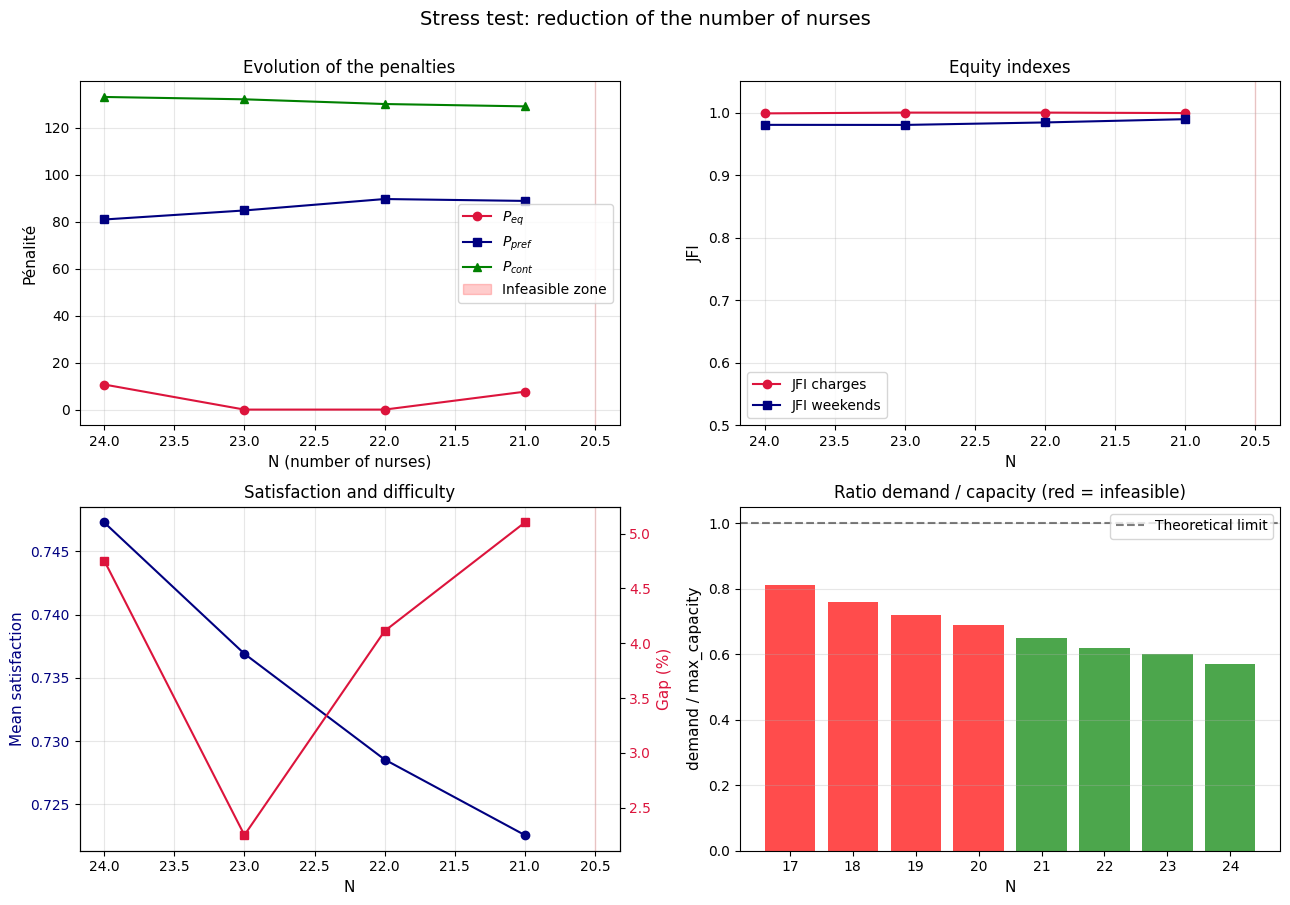

In [31]:
def plot_stress_test(df_stress, savepath=None):
    """Traces the evolution of the metrics with respect to N."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # Filters only the cases with solution
    df_ok = df_stress[~df_stress['no_solution']].copy()

    # Identifies the breaking point
    breaking_N = None
    if df_stress['infeasible'].any():
        breaking_N = df_stress[df_stress['infeasible']]['N'].max()

    # 1. Penalties vs N
    ax = axes[0, 0]
    ax.plot(df_ok['N'], df_ok['P_eq'], 'o-', color='crimson', label=r'$P_{eq}$')
    ax.plot(df_ok['N'], df_ok['P_pref'], 's-', color='navy', label=r'$P_{pref}$')
    ax.plot(df_ok['N'], df_ok['P_cont'], '^-', color='green', label=r'$P_{cont}$')
    if breaking_N:
        ax.axvspan(df_ok['N'].min() - 0.5, breaking_N + 0.5,
                   alpha=0.2, color='red', label='Infeasible zone')
    ax.set_xlabel('N (number of nurses)', fontsize=11)
    ax.set_ylabel('Pénalité', fontsize=11)
    ax.set_title('Evolution of the penalties', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()  # N décroissant pour montrer le stress

    # 2. JFI vs N
    ax = axes[0, 1]
    ax.plot(df_ok['N'], df_ok['JFI_charges'], 'o-', color='crimson', label='JFI charges')
    ax.plot(df_ok['N'], df_ok['JFI_weekends'], 's-', color='navy', label='JFI weekends')
    if breaking_N:
        ax.axvspan(df_ok['N'].min() - 0.5, breaking_N + 0.5, alpha=0.2, color='red')
    ax.set_xlabel('N', fontsize=11)
    ax.set_ylabel('JFI', fontsize=11)
    ax.set_title('Equity indexes', fontsize=12)
    ax.set_ylim(0.5, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()

    # 3. Pref mean + gap vs N
    ax = axes[1, 0]
    ax.plot(df_ok['N'], df_ok['pref_mean'], 'o-', color='navy')
    ax.set_xlabel('N', fontsize=11)
    ax.set_ylabel('Mean satisfaction', color='navy', fontsize=11)
    ax.tick_params(axis='y', labelcolor='navy')
    if breaking_N:
        ax.axvspan(df_ok['N'].min() - 0.5, breaking_N + 0.5, alpha=0.2, color='red')
    ax2 = ax.twinx()
    ax2.plot(df_ok['N'], df_ok['gap'] * 100, 's-', color='crimson')
    ax2.set_ylabel('Gap (%)', color='crimson', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='crimson')
    ax.set_title('Satisfaction and difficulty', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()

    # 4. Ratio demanda/capacità + status
    ax = axes[1, 1]
    colors = ['green' if not inf else 'red' for inf in df_stress['infeasible']]
    ax.bar(df_stress['N'], df_stress['ratio_demand_capacity'], color=colors, alpha=0.7)
    ax.axhline(1.0, color='black', linestyle='--', alpha=0.5,
               label='Theoretical limit')
    ax.set_xlabel('N', fontsize=11)
    ax.set_ylabel('demand / max_capacity', fontsize=11)
    ax.set_title('Ratio demand / capacity (red = infeasible)', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle("Stress test: reduction of the number of nurses",
                 fontsize=14, y=1.00)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=150)
    plt.show()


plot_stress_test(df_stress, savepath=f'{RESULTS_DIR}/stress_test_N.pdf')

## §12 — Experiment 8: 2x2 factorial design (added after submission)

Joint effect of the two candidate fixes for the consecutive-night blocks reported in §6.5 of the
report: the **strict 11 h statutory rest** (forbidding A->M and N->A in addition to N->M) and a
**night-dispersion penalty**. Run across all three approaches, with 3 replicates per cell,
`Threads = 1` for determinism, and differences **paired by seed** — the effects being measured are
of the same order as solver noise, so unpaired medians are not enough.

A single shared evaluator scores all three approaches (see "Known issues" #1 in the README).
Runtime ~4.4 h.

In [32]:
# =====================================================================
# §12 - JOINT impact of the strict 11 h rest (french_workcode) and of the
#        night-dispersion penalty, across ALL THREE approaches.
#
#        2x2 factorial:  base | +P_nc | +11 h rest | both
#        Approaches   :  cold MILP | simulated annealing | hybrid (warm XGB)
#        Instance     :  reference (N=25, seed 42), cf. §6.5 of the report
#
# METHODOLOGICAL NOTE - read before running.
#   The MILP and SA implementations of P_cont diverge in this notebook:
#     MILP: c[n,d] >= x[n,d,s] - x[n,d+1,s], s in {M,A,N}  -> "leaving a
#           work shift"            (M->M = 0, M->R = 1, NNNN block = 1)
#     SA   : +1 si arr[n,d] != R et arr[n,d+1] != R          -> "deux days
#           consecutive worked days" (M->M = 1, M->R = 0, NNNN block = 3)
#   They diverge most sharply on night blocks - precisely the object of this
#   experiment. Here: ONE shared evaluator (MILP semantics, i.e. §4 of the
#   report) for all three approaches; ALIGN_SA_PCONT also aligns the function
#   the SA actually *optimises* (otherwise it optimises A and is scored on B).
#   ALIGN_SA_PCONT = False reproduces the Table 4 SA behaviour.
# =====================================================================

import time, json, itertools

# ----------------------------- configuration -----------------------------
ALPHA_NC        = 1.0          # weight of P_nightconsec (§6.5 control)
BUDGET          = 300          # MILP / hybrid budget (s), as in Table 4
MIP_GAP         = 0.01
SA_SEEDS_EXT    = range(5)     # 5 seeds (10 = comme Tableau 4, mais x2 le temps)
ALIGN_SA_PCONT  = True         # align the P_cont the SA optimises with the MILP one
SHORT_PROBE     = True         # cold vs warm probe at a short budget (distribution shift)
PROBE_BUDGET    = 60
GATE            = True         # check that the "base" arm reproduces the §1 model
WEIGHTS         = {'eq': 1.0, 'we': 1.0, 'pref': 2.0, 'cont': 0.5}
FACT_CACHE      = f'{RESULTS_DIR}/factorial_2x2_3approches.pkl'

ARMS = [
    ('base',        False, False),
    ('C1_nuits',    False, True ),
    ('C2_repos11h', True,  False),
    ('C3_combine',  True,  True ),
]

M_, A_, N_, R_ = 0, 1, 2, 3

# --------------------- SHARED evaluator (all 3 approaches) -----------------
def eval_arr(arr, inst, strict_rest, weights=None):
    """All metrics recomputed from the solution, using the §4 semantics."""
    w = WEIGHTS
    Nn, Dd = inst.N, inst.D

    charges = np.array([(arr[n] != R_).sum() for n in range(Nn)], float)
    nuits   = np.array([(arr[n] == N_).sum() for n in range(Nn)], float)
    wework  = np.array([sum(1 for d in inst.weekend_days if arr[n, d] != R_)
                        for n in range(Nn)], float)

    P_eq = float(np.abs(charges - charges.mean()).sum())
    WE_target = sum(inst.Req[d, s] for d in inst.weekend_days for s in inst.shifts) / Nn
    P_we = float(np.abs(wework - WE_target).sum())

    i2s = {M_: 'M', A_: 'A', N_: 'N'}
    P_pref = float(sum(1 - inst.pref[n, d, i2s[arr[n, d]]]
                       for n in range(Nn) for d in range(Dd) if arr[n, d] != R_))

    # P_cont - MILP semantics: leaving a work shift
    P_cont = float(sum(1 for n in range(Nn) for d in range(Dd - 1)
                       if arr[n, d] != R_ and arr[n, d] != arr[n, d + 1]))

    P_nc = int(sum(1 for n in range(Nn) for d in range(Dd - 1)
                   if arr[n, d] == N_ and arr[n, d + 1] == N_))

    maxrun = 0
    for n in range(Nn):
        r = 0
        for d in range(Dd):
            r = r + 1 if arr[n, d] == N_ else 0
            maxrun = max(maxrun, r)

    Z_core = w['eq'] * P_eq + w['we'] * P_we + w['pref'] * P_pref + w['cont'] * P_cont

    viol = dict(count_hard_violations(arr, inst))          # H2..H6 from the notebook
    viol['H3b'] = 0
    if strict_rest:
        viol['H3b'] = int(sum(1 for n in range(Nn) for d in range(Dd - 1)
                              if (arr[n, d] == A_ and arr[n, d + 1] == M_)
                              or (arr[n, d] == N_ and arr[n, d + 1] == A_)))
    v_tot = sum(val for k, val in viol.items() if k != 'total') if 'total' in viol \
            else sum(viol.values())

    jfi = lambda v: 1.0 if (v * v).sum() == 0 else float(v.sum() ** 2 / (len(v) * (v * v).sum()))

    return {
        'Z_core': round(Z_core, 2), 'P_eq': round(P_eq, 2), 'P_we': round(P_we, 2),
        'P_pref': round(P_pref, 2), 'P_cont': P_cont, 'P_nc': P_nc,
        'max_nuits_consec': maxrun, 'violations': int(v_tot),
        'JFI_charges': round(jfi(charges), 3), 'JFI_nuits': round(jfi(nuits), 3),
        'JFI_weekends': round(jfi(wework), 3),
    }

# ----------------------------- extended MILP -------------------------------
def build_milp_ext(inst, strict_rest=False, night_disp=False, weights=None,
                   time_limit=BUDGET, mip_gap=MIP_GAP, warm_start=None,
                   seed=42, verbose=0):
    """§1 model + optional strict 11 h rest + optional P_nightconsec."""
    w = WEIGHTS
    m = gp.Model("NSP_ext", env=GRB_ENV)
    m.Params.OutputFlag = verbose
    m.Params.TimeLimit = time_limit
    m.Params.MIPGap = mip_gap
    m.Params.Seed = seed

    x = m.addVars([(n, d, s) for n in range(inst.N) for d in range(inst.D)
                   for s in inst.shifts_all], vtype=GRB.BINARY, name="x")
    if warm_start is not None:
        for k, v in warm_start.items():
            x[k].Start = v

    m.addConstrs((quicksum(x[n, d, s] for s in inst.shifts_all) == 1
                  for n in range(inst.N) for d in range(inst.D)), name="H1")
    m.addConstrs((quicksum(x[n, d, s] for n in range(inst.N)) >= inst.Req[d, s]
                  for d in range(inst.D) for s in inst.shifts), name="H2")
    m.addConstrs((x[n, d, 'N'] + x[n, d + 1, 'M'] <= 1
                  for n in range(inst.N) for d in range(inst.D - 1)), name="H3")
    if strict_rest:                                     # 11 h rest: also forbid A->M and N->A
        m.addConstrs((x[n, d, 'A'] + x[n, d + 1, 'M'] <= 1
                      for n in range(inst.N) for d in range(inst.D - 1)), name="H3b_AM")
        m.addConstrs((x[n, d, 'N'] + x[n, d + 1, 'A'] <= 1
                      for n in range(inst.N) for d in range(inst.D - 1)), name="H3b_NA")
    m.addConstrs((quicksum(x[n, d + k, s] for k in range(inst.W_max + 1)
                           for s in inst.shifts) <= inst.W_max
                  for n in range(inst.N)
                  for d in range(inst.D - inst.W_max)), name="H4")
    m.addConstrs((quicksum(x[n, d, 'N'] for d in range(inst.D)) <= inst.N_max
                  for n in range(inst.N)), name="H5")

    wp = inst.weekend_pairs
    f = m.addVars([(n, k) for n in range(inst.N) for k in range(len(wp))],
                  vtype=GRB.BINARY, name="f")
    for n in range(inst.N):
        for k, (sat, sun) in enumerate(wp):
            m.addConstr(f[n, k] <= x[n, sat, 'R'])
            m.addConstr(f[n, k] <= x[n, sun, 'R'])
            if warm_start is not None:
                f[n, k].Start = 1.0 if (warm_start.get((n, sat, 'R'), 0) > 0.5 and
                                        warm_start.get((n, sun, 'R'), 0) > 0.5) else 0.0
        m.addConstr(quicksum(f[n, k] for k in range(len(wp))) >= inst.WE_min)

    P_pref = quicksum((1 - inst.pref[n, d, s]) * x[n, d, s]
                      for n in range(inst.N) for d in range(inst.D) for s in inst.shifts)
    c = m.addVars([(n, d) for n in range(inst.N) for d in range(inst.D - 1)],
                  lb=0.0, ub=1.0, name="c")
    for n in range(inst.N):
        for d in range(inst.D - 1):
            for s in inst.shifts:
                m.addConstr(c[n, d] >= x[n, d, s] - x[n, d + 1, s])
    P_cont = quicksum(c[n, d] for n in range(inst.N) for d in range(inst.D - 1))

    W = {n: quicksum(x[n, d, s] for d in range(inst.D) for s in inst.shifts)
         for n in range(inst.N)}
    W_bar = quicksum(W[n] for n in range(inst.N)) / inst.N
    dp = m.addVars(range(inst.N), lb=0); dm = m.addVars(range(inst.N), lb=0)
    for n in range(inst.N):
        m.addConstr(W[n] - W_bar == dp[n] - dm[n])
    P_eq = quicksum(dp[n] + dm[n] for n in range(inst.N))

    WEw = {n: quicksum(x[n, d, s] for d in inst.weekend_days for s in inst.shifts)
           for n in range(inst.N)}
    WE_target = sum(inst.Req[d, s] for d in inst.weekend_days
                    for s in inst.shifts) / inst.N
    gp_ = m.addVars(range(inst.N), lb=0); gm_ = m.addVars(range(inst.N), lb=0)
    for n in range(inst.N):
        m.addConstr(WEw[n] - WE_target == gp_[n] - gm_[n])
    P_we = quicksum(gp_[n] + gm_[n] for n in range(inst.N))

    P_nc = gp.LinExpr(0.0)
    if night_disp:                                      # z >= x_N,d + x_N,d+1 - 1
        z = m.addVars([(n, d) for n in range(inst.N) for d in range(inst.D - 1)],
                      lb=0.0, ub=1.0, name="z")
        for n in range(inst.N):
            for d in range(inst.D - 1):
                m.addConstr(z[n, d] >= x[n, d, 'N'] + x[n, d + 1, 'N'] - 1)
        P_nc = quicksum(z[n, d] for n in range(inst.N) for d in range(inst.D - 1))

    m.setObjective(w['eq'] * P_eq + w['we'] * P_we + w['pref'] * P_pref
                   + w['cont'] * P_cont + ALPHA_NC * P_nc, GRB.MINIMIZE)
    m.optimize()

    if m.SolCount == 0:
        return None, {'runtime_s': round(m.Runtime, 1), 'gap_pct': None}
    arr = np.full((inst.N, inst.D), R_, dtype=np.int8)
    s2i = {s: i for i, s in enumerate(inst.shifts_all)}
    for n in range(inst.N):
        for d in range(inst.D):
            for s in inst.shifts_all:
                if x[n, d, s].X > 0.5:
                    arr[n, d] = s2i[s]
    return arr, {'runtime_s': round(m.Runtime, 1), 'gap_pct': round(100 * m.MIPGap, 2)}

# ------------------- SA: extended energy (monkey-patch) --------------------
if '_compute_energy_base' not in globals():
    _compute_energy_base = compute_energy          # keep the original around

EXT_STRICT_REST = False        # driven by the runner
EXT_NIGHT_DISP  = False

def compute_energy(arr, inst, weights, lambda_hard=1000.0):      # noqa: F811
    """SA energy = Z + lambda*V, optionally with strict rest in V and P_nc in Z."""
    soft = compute_soft_penalties(arr, inst)
    hard = count_hard_violations(arr, inst)

    if ALIGN_SA_PCONT:      # same P_cont as the MILP (see the note at the top of this cell)
        soft = dict(soft)
        soft['P_cont'] = float(sum(1 for n in range(inst.N) for d in range(inst.D - 1)
                                   if arr[n, d] != R_ and arr[n, d] != arr[n, d + 1]))
    v_tot = hard['total']
    if EXT_STRICT_REST:
        v_tot += sum(1 for n in range(inst.N) for d in range(inst.D - 1)
                     if (arr[n, d] == A_ and arr[n, d + 1] == M_)
                     or (arr[n, d] == N_ and arr[n, d + 1] == A_))
    Z = (weights['eq'] * soft['P_eq'] + weights['we'] * soft['P_we']
         + weights['pref'] * soft['P_pref'] + weights['cont'] * soft['P_cont'])
    if EXT_NIGHT_DISP:
        Z += ALPHA_NC * sum(1 for n in range(inst.N) for d in range(inst.D - 1)
                            if arr[n, d] == N_ and arr[n, d + 1] == N_)
    return Z + lambda_hard * v_tot, soft, hard

In [33]:
# ==========================================================================
# §8 — EXÉCUTION v3
#   fixes: (a) the print IndexError, (b) the warm start is no longer refused
#   mais toudays transmis (c'est à Gurobi de le réparer — cf. §5.3 : la
#   projection only guarantees H1), (c) a pre-flight diagnostic of
#   x-hat admissibility, with no solver involved.
#
#   Replaces everything after "# ---- run ----" in the §12 cell.
# ==========================================================================

import numpy as np, pandas as pd, os, time

# ------------------------------ configuration ------------------------------
MILP_SEEDS   = [42, 7, 2026]
SA_SEEDS_EXT = range(5)
SHORT_PROBE  = True
PROBE_BUDGET = 60
FACT_CACHE   = f'{RESULTS_DIR}/factorial_2x2_repl.pkl'

GRB_ENV.setParam('Threads', 1)             # determinism at a fixed seed
GRB_ENV.setParam('StartNodeLimit', 20000)  # repair budget for the MIP start

_SA_KW = SA_PARAMS if 'SA_PARAMS' in globals() else {}

# --------------------------- warm-start helpers ----------------------------
def _ws_to_arr(ws, inst):
    arr = np.full((inst.N, inst.D), R_, dtype=np.int8)
    s2i = {s: i for i, s in enumerate(inst.shifts_all)}
    for n in range(inst.N):
        for d in range(inst.D):
            for s in inst.shifts_all:
                if ws.get((n, d, s), 0) > 0.5:
                    arr[n, d] = s2i[s]
    return arr

def _arr_to_ws(arr, inst):
    return {(n, d, s): (1 if arr[n, d] == i else 0)
            for n in range(inst.N) for d in range(inst.D)
            for i, s in enumerate(inst.shifts_all)}

def _viol_detail(arr, inst, strict_rest=False):
    """Per-constraint violation counts on an assignment matrix."""
    h = dict(count_hard_violations(arr, inst))
    h.pop('total', None)
    if strict_rest:
        h['H3b'] = int(sum(1 for n in range(inst.N) for d in range(inst.D - 1)
                           if (arr[n, d] == A_ and arr[n, d + 1] == M_)
                           or (arr[n, d] == N_ and arr[n, d + 1] == A_)))
    h['TOTAL'] = int(sum(h.values()))
    return h

def _repair_h2(arr, inst):
    """Fill missing coverage using nurses resting on that day."""
    rep = arr.copy()
    for d in range(inst.D):
        for si, s in enumerate(inst.shifts):
            manque = inst.Req[d, s] - int((rep[:, d] == si).sum())
            if manque <= 0:
                continue
            libres = [n for n in range(inst.N) if rep[n, d] == R_]
            for n in libres[:manque]:
                rep[n, d] = si
    return rep

def prepare_warm_start(inst, model, strict_rest, verbose=True):
    """Return (ws, status). The start is ALWAYS passed on: if x-hat remains
    infeasible, repairing it is the solver's job (StartNodeLimit)."""
    pred = predict_warm_start(inst, model, None, 'xgb')
    arr0 = _ws_to_arr(pred['binary'], inst)
    v0   = _viol_detail(arr0, inst, strict_rest)
    if v0['TOTAL'] == 0:
        if verbose: print("      warm-start : admissible d'emblée")
        return pred['binary'], 'complet'

    rep = _repair_h2(arr0, inst)
    v1  = _viol_detail(rep, inst, strict_rest)
    if v1['TOTAL'] == 0:
        if verbose: print(f"      warm-start : {v0['TOTAL']} viol. -> réparé (H2)")
        return _arr_to_ws(rep, inst), 'réparé'

    best, vb, tag = ((rep, v1, 'brut+H2') if v1['TOTAL'] < v0['TOTAL']
                     else (arr0, v0, 'brut'))
    if verbose:
        det = {k: n for k, n in vb.items() if k != 'TOTAL' and n > 0}
        print(f"      warm-start : {vb['TOTAL']} violations résiduelles {det} "
              f"-> transmis quand même ({tag}), réparation laissée au solveur")
    return _arr_to_ws(best, inst), f'{tag} ({vb["TOTAL"]} viol.)'

# ---------------- pre-flight diagnostic (no solver, ~5 s) ------------------
print("=========== Diagnostic: is the x-hat prediction feasible? ===========")
_diag = [('référence', inst)]
if 'insts_test' in globals() and len(insts_test):
    _diag += [(f'test[{i}]', insts_test[i]) for i in range(min(3, len(insts_test)))]
for _nom, _i in _diag:
    _a = _ws_to_arr(predict_warm_start(_i, xgb_model, None, 'xgb')['binary'], _i)
    _v = _viol_detail(_a, _i)
    print(f"  {_nom:12s} N={_i.N:3d}  x-hat violations: "
          f"{ {k: n for k, n in _v.items() if n > 0} }")
print("  -> if the TEST instances are violated too, the Figure 1 gain came "
      "from the solver repairing the start, not from an accepted start.\n")

# --------------------------------- runner ----------------------------------
def run_factorial_repl(inst, warm_model=None):
    rows = []
    for arm, strict, ndisp in ARMS:
        print(f"\n=== {arm}  (11 h rest: {strict} | P_nc: {ndisp}) ===", flush=True)
        ws, ws_status = (None, 'n/a')
        if warm_model is not None:
            ws, ws_status = prepare_warm_start(inst, warm_model, strict)

        for rep, gseed in enumerate(MILP_SEEDS):
            arr, meta = build_milp_ext(inst, strict, ndisp, seed=gseed)
            r = eval_arr(arr, inst, strict); r.update(meta)
            r.update(arm=arm, approche='MILP', rep=rep, seed=gseed,
                     budget=BUDGET, ws_status='n/a')
            rows.append(r)
            msg = f"  [rep {rep} | seed {gseed}] MILP Z={r['Z_core']}"

            if ws is not None:
                arw, mw = build_milp_ext(inst, strict, ndisp, seed=gseed, warm_start=ws)
                rw = eval_arr(arw, inst, strict); rw.update(mw)
                rw.update(arm=arm, approche='hybride', rep=rep, seed=gseed,
                          budget=BUDGET, ws_status=ws_status)
                rows.append(rw)
                msg += f" | hybride Z={rw['Z_core']}  (Δ={rw['Z_core'] - r['Z_core']:+.2f})"

            if SHORT_PROBE:
                for tag, w_ in [('cold@60', None), ('warm@60', ws)]:
                    if tag == 'warm@60' and ws is None:
                        continue
                    a2, m2 = build_milp_ext(inst, strict, ndisp, seed=gseed,
                                            time_limit=PROBE_BUDGET, warm_start=w_)
                    r2 = eval_arr(a2, inst, strict) if a2 is not None else {'Z_core': np.nan}
                    r2.update(m2); r2.update(arm=arm, approche=tag, rep=rep, seed=gseed,
                                             budget=PROBE_BUDGET, ws_status=ws_status)
                    rows.append(r2)
            print(msg, flush=True)

        global EXT_STRICT_REST, EXT_NIGHT_DISP
        EXT_STRICT_REST, EXT_NIGHT_DISP = strict, ndisp
        for rep, sd in enumerate(SA_SEEDS_EXT):
            out = simulated_annealing(inst, weights=WEIGHTS, seed=sd,
                                      verbose=False, **_SA_KW)
            rs = eval_arr(out['best_arr'], inst, strict)
            rs.update(arm=arm, approche='SA', rep=rep, seed=sd,
                      budget=None, runtime_s=None, gap_pct=None, ws_status='n/a')
            rows.append(rs)
        EXT_STRICT_REST, EXT_NIGHT_DISP = False, False

        df_a = pd.DataFrame([r for r in rows if r['arm'] == arm])
        print("  médianes Z :", df_a.groupby('approche')['Z_core'].median().round(2).to_dict(),
              flush=True)
    return pd.DataFrame(rows)

# ------------------------------------ run ----------------------------------
if GATE:
    print("Gate: the 'base' arm must reproduce the §1 model ...")
    ag, mg = build_milp_ext(inst, False, False, seed=MILP_SEEDS[0])
    g = eval_arr(ag, inst, False)
    print(f"  base ext : Z_core={g['Z_core']}  gap={mg['gap_pct']} %  viol={g['violations']}")
    print("  -> compare on Z_core ONLY (individual penalties move by +/-8% "
          "at equal gap).")

n_milp = len(ARMS) * len(MILP_SEEDS) * (2 + (2 if SHORT_PROBE else 0))
print(f"\n≈ {(n_milp * BUDGET / 2 + len(ARMS) * len(list(SA_SEEDS_EXT)) * 250) / 3600:.1f} h "
      f"estimated ({n_milp} MILP runs + {len(ARMS) * len(list(SA_SEEDS_EXT))} SA runs)\n")

if not FORCE_RERUN and os.path.exists(FACT_CACHE):
    df_fact = pd.read_pickle(FACT_CACHE)
    print(f"Reloaded from {FACT_CACHE}")
else:
    t0 = time.time()
    df_fact = run_factorial_repl(inst, warm_model=xgb_model)
    df_fact.to_pickle(FACT_CACHE)
    print(f"\nCompleted in {(time.time() - t0) / 3600:.2f} h")

# -------------------------------- reporting --------------------------------
print("\n=========== Factorial design - medians over replicates ===========")
print(df_fact.pivot_table(index='arm', columns='approche',
                          values=['Z_core', 'P_nc', 'max_nuits_consec'],
                          aggfunc='median').to_string())

print("\n=========== Noise floor (same configuration, different seeds) ===========")
for app in df_fact['approche'].unique():
    b = df_fact[(df_fact['arm'] == 'base') & (df_fact['approche'] == app)]['Z_core'].dropna()
    if len(b) > 1:
        print(f"  {app:10s} n={len(b)}  étendue Z = {b.max() - b.min():.2f} pt  "
              f"{[round(v, 2) for v in b]}")

print("\n=========== PAIRED effects per replicate (delta% on Z_core vs base) ===========")
print("   an effect only counts if it clearly exceeds the noise floor above")
for app in df_fact['approche'].unique():
    sub = df_fact[df_fact['approche'] == app]
    base_by_rep = sub[sub['arm'] == 'base'].set_index('rep')['Z_core']
    if base_by_rep.empty:
        continue
    eff, line = {}, f"  {app:10s}"
    for arm, _, _ in ARMS:
        if arm == 'base':
            continue
        a = sub[sub['arm'] == arm].set_index('rep')['Z_core']
        common = base_by_rep.index.intersection(a.index)
        if len(common) == 0:
            continue
        d = [100 * (a[r] - base_by_rep[r]) / base_by_rep[r] for r in common]
        eff[arm] = (float(np.median(d)), min(d), max(d))
        line += f"  {arm.split('_')[0]}={eff[arm][0]:+5.2f} [{eff[arm][1]:+5.2f},{eff[arm][2]:+5.2f}]"
    if all(k in eff for k in ('C1_nuits', 'C2_repos11h', 'C3_combine')):
        line += (f"  → interaction "
                 f"{eff['C3_combine'][0] - eff['C1_nuits'][0] - eff['C2_repos11h'][0]:+5.2f} pt")
    if eff:
        print(line)

print("\n=========== Warm-start effect (paired, same seed) ===========")
for bud in ([BUDGET, PROBE_BUDGET] if SHORT_PROBE else [BUDGET]):
    cold_app = 'MILP' if bud == BUDGET else 'cold@60'
    warm_app = 'hybride' if bud == BUDGET else 'warm@60'
    for arm, _, _ in ARMS:
        cc = df_fact[(df_fact['arm'] == arm) & (df_fact['approche'] == cold_app)].set_index('rep')['Z_core']
        wwr = df_fact[(df_fact['arm'] == arm) & (df_fact['approche'] == warm_app)].set_index('rep')['Z_core']
        common = cc.index.intersection(wwr.index)
        if len(common) == 0:
            continue
        d = [wwr[r] - cc[r] for r in common]
        flag = "identical -> start rejected" if all(abs(v) < 1e-9 for v in d) else ""
        print(f"  budget {bud:3d}s  {arm:12s} Δ(warm-cold) médian = {np.median(d):+6.2f} "
              f"[{min(d):+.2f},{max(d):+.2f}]  {flag}")

print("\n=========== Night blocks (P_nc) ===========")
for app in ('MILP', 'SA', 'hybride'):
    sub = df_fact[df_fact['approche'] == app]
    if sub.empty:
        continue
    med = sub.groupby('arm')['P_nc'].median().to_dict()
    rng = sub.groupby('arm')['P_nc'].agg(lambda v: f"[{v.min():.0f},{v.max():.0f}]").to_dict()
    print(f"  {app:10s} " + "  ".join(f"{a}={med.get(a, float('nan')):.0f}{rng.get(a, '')}"
                                      for a, _, _ in ARMS))

print("\n=========== Warm-start status ===========")
w = df_fact[df_fact['approche'] == 'hybride'].groupby('arm')['ws_status'].first()
print(w.to_string() if not w.empty else "  (aucun bras hybride)")

Set parameter Threads to value 1
Set parameter StartNodeLimit to value 20000
=========== Diagnostic: is the x-hat prediction feasible? ===========
  référence    N= 27  x-hat violations: {'H2': 176, 'H3': 1, 'TOTAL': 177}
  test[0]      N= 22  x-hat violations: {'H2': 144, 'H3': 7, 'H4': 1, 'H6': 1, 'TOTAL': 153}
  test[1]      N= 26  x-hat violations: {'H2': 170, 'H3': 2, 'H6': 2, 'TOTAL': 174}
  test[2]      N= 22  x-hat violations: {'H2': 140, 'H3': 9, 'H5': 1, 'TOTAL': 150}
  -> if the TEST instances are violated too, the Figure 1 gain came from the solver repairing the start, not from an accepted start.

Gate: the 'base' arm must reproduce the §1 model ...
  base ext : Z_core=231.4  gap=1.93 %  viol=0
  -> compare on Z_core ONLY (individual penalties move by +/-8% at equal gap).

≈ 3.4 h estimated (48 MILP runs + 20 SA runs)

Reloaded from /content/drive/MyDrive/NSP_results/factorial_2x2_repl.pkl

=========== Factorial design - medians over replicates ===========
             P_nc

## Summary — mapping to the report

| Output of this notebook | Element of the report |
|---|---|
| §4 `report(...)` | Table 4 — MILP vs SA at 300 s |
| §6 aggregation | Table 5, warm column — fairness inherited by the hybrid |
| §7 `fig1a…fig1d` | Figure 1 — cold vs warm start, 5→60 s budgets |
| §8 `shap_*.pdf` | Figure 3 — SHAP analysis (E3) |
| §9 `pareto_*.pdf` | Figure 2 — Pareto fronts, weight calibration (E1) |
| §10 `robustness_summary.csv`, `sa_robustness.csv` | Table 6 — robustness to P1–P3 |
| §11 `stress_test_N.pdf` | Scaling analysis over N |
| §12 factorial table | Post-submission experiment, not in the report |

**Reproducibility.** Seeds are fixed throughout (instances: one seed per specification; split: 42;
ML: 42; Gurobi: 42, with `Threads=1` in §12). Incumbent values at a fixed budget still depend on
solver performance and therefore on the machine.

**Not included here:** the §6.5 control experiments in their original single-run form — superseded by
the factorial design of §12, which replicates them with proper controls.